In [1]:
from math import gcd 
import math
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import random
from datetime import datetime
import copy as cp

import qiskit
from qiskit import assemble, transpile
from qiskit.providers.aer.noise import NoiseModel
from qiskit.providers.aer.noise.errors.standard_errors import depolarizing_error, thermal_relaxation_error
import qiskit.ignis.verification.randomized_benchmarking as rb

qiskit.__version__, sys.version

C:\Users\Timo\AppData\Local\Temp\ipykernel_32540\213096259.py:15: DeprecationWarning: The qiskit.ignis package is deprecated and has been supersceded by the qiskit-experiments project. Refer to the migration guide: https://github.com/Qiskit/qiskit-ignis#migration-guide on how to migrate to the new project.
  import qiskit.ignis.verification.randomized_benchmarking as rb


('0.25.1',
 '3.8.16 (default, Jan 17 2023, 22:25:28) [MSC v.1916 64 bit (AMD64)]')

In [3]:
# enable qiskit loggers
import logging
excl_loggers = ['matplotlib', 'IPKernelApp']

logging.basicConfig(level=logging.DEBUG)

all_on = False

# activate all loggers (set to low level):
for loggerStr in logging.Logger.manager.loggerDict:
    logger = logging.getLogger(loggerStr)
    if not  logger.name in excl_loggers:
        logger.propagate = all_on
        logger.setLevel(logging.DEBUG)
    else:
        logger.propagate = all_on
        logger.setLevel(logging.DEBUG)
    
logger = logging.getLogger() 

logger.debug("test")
0

DEBUG:root:test


0

# Library

In [4]:
def optimize_circ_q1(qc):
    optimizer = qiskit.transpiler.passes.Optimize1qGatesDecomposition(basis=['rx','ry'])#, target=target)#

    qc_dag = qiskit.converters.circuit_to_dag(qc)
    qc_dag = optimizer.run(qc_dag)
    qc_opt = qiskit.converters.dag_to_circuit(qc_dag)
    
    return qc_opt


def add_qudi_gate(qc, qd_gate, swap_qubits=False, mirror_1q=False):
    gate_str = qd_gate[0][0]
    gate_params = qd_gate[0][1]
    qubit = qd_gate[1]
    
    if swap_qubits:
        if len(qubit) == 1:
            qubit = [1] if qubit == [0] else [0]
        elif len(qubit) == 2:
            qubit = list(reversed(qubit))
        else:
            raise NotImplemented
    
    if mirror_1q:
        # todo: broken. not correct qiskit quantumreg
        if len(qubit) != 1:
            raise ValueError
        else:
            qubit = [0,1]
    
    if gate_str == 'rx':
        qc.rx(gate_params[0], qubit)
    elif gate_str == 'ry':
        qc.ry(gate_params[0], qubit)
    elif gate_str == 'cx':
        #pass
        qc.cx(qubit[1], qubit[0])
    elif gate_str == 'c2phase1':
        #pass
        qc.append(get_gate_c2phase1(), [0,1])
    elif gate_str == 'barrier':
        qc.barrier(qubit)
    elif gate_str == 'measure':
        qc.measure(qubit, 0)
    else:
        raise ValueError(f"Didn't understand gate {qd_gate}")

def filter_same_n_cnot(rb_circs):
    rb_circs_filtered = []
    n_clif_vec = len(rb_circs)
    for i in range(0, n_clif_vec):
        circs_i = []

        n_cnots = [get_n_cx(c) for c in rb_circs[i]]
        most_common = max(set(n_cnots), key = n_cnots.count)
        n_cnots_target = most_common
                
        filtered = filter(lambda c: get_n_cx(c) == n_cnots_target, rb_circs[i])
        rb_circs_filtered.append(list(filtered))
    return rb_circs_filtered

def clip_n_gates(rb_circs, clip_factor=1.):
    rb_circs = rb_circs_native

    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs

    rb_circs_filtered = []
    n_clif_vec = len(rb_circs)
    circs_i = []
    for i in range(0, n_clif_vec):
        circs_j = []
        for j in range(0, len(rb_circs[i])):
            circ = rb_circs[i][j]
            qc = qiskit.QuantumCircuit(*qregs, *cregs)
            for idx, g in enumerate(circ):
                if idx <= clip_factor*len(circ):
                    qc.data.append(g)

            circs_j.append(qc)            
        circs_i.append(circs_j)

    return circs_i


def filter_gate(rb_circs, filter_gate='cx'):
    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs
        
    rb_circs_filtered = []
    n_clif_vec = len(rb_circs)
    circs_i = []
    for i in range(0, n_clif_vec):
        circs_j = []
        for j in range(0, len(rb_circs[i])):
            #circs_j.append([gate for gate in rb_circs[i][j].data if not gate[0].name == filter_gate])
            circ = rb_circs[i][j]
            qc = qiskit.QuantumCircuit(*qregs, *cregs)
            for g in circ:
                if g[0].name != filter_gate:
                    qc.data.append(g)
                    
            circs_j.append(qc)            
        circs_i.append(circs_j)
        
    return circs_i

def clip_same_n_rand(rb_circs):
    n_rand = [len(circs) for circs in rb_circs]
    min_n = np.min(n_rand)
    
    rb_circs_out = []
    
    for i in range(0, len(rb_circs)):
        rb_circs_rand = []
        for j in range(0, min_n):
            rb_circs_rand.append(rb_circs[i][j])
        rb_circs_out.append(rb_circs_rand)

    return rb_circs_out

def calc_cx(rb_circs):
    # calculate number of cnots per xdata step
    arr = np.zeros((len(rb_circs),len(rb_circs[0])))
    for i in range(0, len(rb_circs)):
        for j in range(0, len(rb_circs[0])):
            arr[i,j] = get_n_cx(rb_circs[i][j])
    return arr

def calc_1q(rb_circs, basis_gates=['ry', 'rx']):
    # calculate number of cnots per xdata step
    arr = np.zeros((len(rb_circs),len(rb_circs[0])))
    for i in range(0, len(rb_circs)):
        for j in range(0, len(rb_circs[0])):
            arr[i,j] = get_n_1q_rot(rb_circs[i][j], basis_gates=basis_gates)
    return arr

def get_n_cx(circ):
    if type(circ) == list:
        # after conversion to qudi format
        return np.sum([el[0][0]=='cx' for el in circ[1]])
    
    return np.sum([el[0].name=='cx' for el in circ.data])

def get_n_1q_rot(circ, basis_gates=['ry', 'rx']):
    if type(circ) == list:
        # after conversion to qudi format
        return np.sum([el[0][0] in basis_gates for el in circ[1]])
    
    elif type(circ) == qiskit.circuit.quantumcircuit.QuantumCircuit:
        return np.sum([el[0].name in basis_gates for el in circ.data])

    raise ValueError 


def is_interleaved(rb_opts):
    if 'interleaved_gates' not in rb_opts:
        return False
    return rb_opts['interleaved_gates'] != []

def circuit_step_2_qubit_idx(cstep, swap_qubits=False):
    qregister = cstep[1]
    if len(qregister) == 2:
        return [0,1]
    elif len(qregister) == 1:
        reg_str = str(qregister[0])
        if ", 1" in reg_str:
            return [1] if not swap_qubits else [0]
        elif ", 0" in reg_str:
            return [0] if not swap_qubits else [1]
    elif len(qregister) > 2:
        raise NotImplementedError

def circuit_step_2_gatestr(cstep):
    try:
        gate_name = cstep[0].name
        if gate_name == "c2phase1" or gate_name == "unitary":
            if np.array_equal(cstep[0].params[0], get_gate_c2phase1().params[0]):
                gate_param = []
                gate_name = "c2phase1"
            else:
                raise ValueError
        else:   
            gate_param = [float(p) for p in cstep[0].params]
        
        return gate_name, gate_param 
    except:
        logger.exception(f"Can't get str from circuit step {cstep}")

def circuit_2_step_list(circ, qubit_idx=0, swap_qubits=False):
    gate_strs, on_nv = [],[]
    for step in circ.data:
       
        gate_strs.append(circuit_step_2_gatestr(step))
        on_nv.append(circuit_step_2_qubit_idx(step, swap_qubits=swap_qubits))
    
    step_list = list(zip(gate_strs, on_nv))
    #return step_list
    return [step for step in step_list if qubit_idx in step[1]]

def serialize_step_list(steps_q0, steps_q1):
    # todo: seems over-complicated, but works
    ser_list = []
    
    idx_0, idx_1 = 0, 0
    while not (idx_0==len(steps_q0) and idx_1==len(steps_q1)):   
        is_end_0, is_end_1 = False, False
        is_2q_0, is_2q_1 = False, False
        try:
            is_2q_0 = len(steps_q0[idx_0][1]) == 2
        except IndexError:
            is_end_0 = True
        try:
            is_2q_1 = len(steps_q1[idx_1][1]) == 2
        except IndexError:
            is_end_1 = True
        
        #print(f"Now list: {ser_list}. \nEnd: {is_end_0}, {is_end_1}, 2q: {is_2q_0}, {is_2q_1}")
        try:
            if (not is_2q_0) and (not is_2q_1) and (not is_end_0) and (not is_end_1):
                ser_list.append(steps_q0[idx_0])
                ser_list.append(steps_q1[idx_1])
                idx_0 += 1
                idx_1 += 1

            elif (is_2q_0) and (not is_2q_1) and (not is_end_1):
                ser_list.append(steps_q1[idx_1])
                idx_1 += 1

            elif (not is_2q_0) and (is_2q_1) and (not is_end_0):
                ser_list.append(steps_q0[idx_0])
                idx_0 += 1

            elif (is_2q_0) and (is_2q_1):
                ser_list.append(steps_q0[idx_0])
                idx_0 += 1
                idx_1 += 1
            elif is_end_0:
                ser_list.append(steps_q1[idx_1])
                idx_1 += 1
            elif is_end_1:
                ser_list.append(steps_q0[idx_0])
                idx_0 += 1
            else:
                raise RuntimeError(f"Failed at idxs {idx_0}, {idx_1}")
                
        except IndexError:
            raise IndexError(f"Failed at idxs {idx_0}, {idx_1}")
        
            
    return ser_list

def endian_big_2_little(matrix):
    # qiskit uses little endian notation, so |01> means q0 = 1
    qubit_count = 2
    u_tensor = np.asarray(matrix).reshape([2] * 2 * qubit_count)
    u_input = list(reversed(range(qubit_count)))
    output = [i + qubit_count for i in u_input]
    little_endian_tensor = np.einsum(u_tensor, u_input + output)
    return little_endian_tensor.reshape([2 ** qubit_count, 2 ** qubit_count])

def endian_little_2_big(matrix):
    # qiskit uses little endian notation, so |01> means q0 = 1
    qubit_count = 2 # for n=2, swapping endianess is equal both ways
    return endian_big_2_little(matrix)

def substitute_cnot(circ, decomp_mode='qiskit'):
    qregs = circ.qregs
    cregs = circ.cregs
    
    c1not2_dec = decompose_c1not2(mode=decomp_mode)
    
    qc = qiskit.QuantumCircuit(*qregs, *cregs)
    for gate in circ:
        try:
            if gate[0].name == 'cx':
                for g in c1not2_dec:
                    if g[0].name == 'c2phase1':
                        qubits = [0,1]
                        qc.append(g[0], qubits)
                    else:
                        qubits = [g[1][0].index] 
                        qc.append(g[0], qubits)
            else:
                g = gate
                qc.data.append(g)
        except:
            logger.exception(f"In gate {g}")

    return qc


0

0

# Create random benchmarking list


In [4]:
params = {}

# number of qubits
params['n_qubits'] = 2
params['force_n_cx_const'] = False # =True breaks simulation
params['strip_cnot'] = False # keep alway false here. May set true in section Manipulate

rb_opts = {}
#Number of Cliffords in the sequence
rb_opts['length_vector'] = [i for i in range(1,10)]
#rb_opts['length_vector'] = [2,4,8,16,32,48,64,96,128,144]
# Number of seeds (random sequences)
rb_opts['nseeds'] = int(50)
# Default pattern
rb_opts['rb_pattern'] = [[0,1]] if params['n_qubits']==2 else [[0]]
# benchmark a specific gate
params['interleaved_rb'] = False
rb_opts['interleaved_gates'] =[] # [[['x']]]#[['cx 0 1']]
# 
rb_opts['length_multiplier'] = 1 # [[['x']]]#[['cx 0 1']]


rb_circs, xdata = rb.randomized_benchmarking_seq(**rb_opts)

# transpose rb_circ st 2nd index is random index
rb_circs = list(map(list, zip(*rb_circs)))
"""
if params['force_n_cx_const']:
    rb_circs = filter_same_n_cnot(rb_circs) 
    rb_circs = clip_same_n_rand(rb_circs)

rb_circs_orig = cp.deepcopy(rb_circs)

# keep copy with original list order for simulation 
rb_circs_orig = list(map(list, zip(*rb_circs_orig)))
rb_circs_native = []

now = datetime.now() # current date and time
params['timestamp'] = now.strftime("%Y%m%d-%H%M-%S")
params['qiskit_version'] = qiskit.__version__
params['rb_options'] = rb_opts


n_cx_percliff = np.mean(calc_cx(rb_circs), axis=1)
if len(np.unique(n_cx_percliff)) != len(n_cx_percliff):
    logger.warning("Unwanted repetition of n_cnots in clifford length vector. Regenerate circuit.")
    raise ValueError("Unwanted repetition of n_cnots in clifford length vector")
"""
params

{'n_qubits': 2,
 'force_n_cx_const': False,
 'strip_cnot': False,
 'interleaved_rb': False}

In [5]:
circ = rb_circs[0][0]
# number of entangling gates per clifford length
n_cx_percliff

array([ 2.,  4.,  6.,  7.,  8., 11., 12., 15., 14.])

In [120]:
n_rand = [len(circs) for circs in rb_circs]
n_rand

[29, 29, 29]

In [6]:
get_n_1q_rot(circ, basis_gates=['h', 'x', 'sdg'])

13

In [91]:
calc_cx(rb_circs), calc_1q(rb_circs, basis_gates=['h', 'x', 'sdg']) 
0

0

In [93]:
# count mean, median Cnots per idx_cliff
np.mean(calc_cx(rb_circs), axis=1), np.median(calc_cx(rb_circs), axis=1)

(array([ 2.,  4.,  6.,  8.,  8., 11., 12., 14.]),
 array([ 2.,  4.,  6.,  8.,  8., 11., 12., 14.]))

In [122]:
# count mean, median 1qs per idx_cliff
np.mean(calc_1q(rb_circs, basis_gates=['h', 'x', 'sdg']), axis=1), np.median(calc_1q(rb_circs, basis_gates=['h', 'x', 'sdg']), axis=1)

(array([ 9.71428571, 13.85714286, 20.23809524, 27.42857143, 29.71428571,
        37.04761905, 42.        , 47.71428571]),
 array([10., 13., 20., 28., 29., 37., 42., 48.]))

## Test U in Clifford

In [6]:
u_cphase =np.asarray([[1, 0,  0,  0],
                      [0, 1j, 0,  0],
                      [0, 0,  1j, 0],
                      [0, 0,  0,  1]])

u_cnot = np.asarray([[1, 0, 0, 0],
                     [0, 1, 0, 0],
                     [0, 0, 0, 1],
                     [0, 0, 1, 0]])


gut = u_cphase
#gut = u_cnot


u_tests = []
all_2q_paulis = []

# generate list of all paulis
for si in ['X', 'Y', 'Z', 'I']:
    for sj in ['X', 'Y', 'Z', 'I']:
        pauli_2q = qiskit.quantum_info.Pauli(si+sj)
        all_2q_paulis.append(pauli_2q)
        
# generate P to be tested for: is UPU^t element Pauli
test_2q_paulis = []
f#or s in ['XI', 'IX', 'ZI', 'IZ']:  # enough according to wiki
for s in [str(p) for p in all_2q_paulis]: 
    pauli_2q = qiskit.quantum_info.Pauli(s)
    test_2q_paulis.append(pauli_2q)
    test_matrix = np.matmul(gut, np.matmul(pauli_2q, gut.conj().T)) 
    u_tests.append(test_matrix)

# test that all UPU^t are in 2Q Pauli group
is_clifford = True
print(f"GUT U= \n{gut}")
for idx_u, t in enumerate(u_tests):
    is_in_pauli = False
    #print(f"New u_test: \n{t}")
    for p in all_2q_paulis:
        is_pauli_i = False
        for global_phase in [-1,1,-1j,-1]:
            is_pauli_i = is_pauli_i or np.array_equiv(p, global_phase*t)
            
        is_in_pauli = is_in_pauli or is_pauli_i
        if is_pauli_i:
            break
            
    if is_in_pauli:
        print(f"UPU^t == Pauli({p}) in Pauli group: {is_in_pauli}, P= {test_2q_paulis[idx_u]}")
    else:
        print(f"UPU^t = \n{t}\n NOT in Pauli group P= {test_2q_paulis[idx_u]}")
    is_clifford =  is_in_pauli and is_clifford

print(f"is_clifford: {is_clifford}")

NameError: name 'f' is not defined

In [776]:
pauli_2q = qiskit.quantum_info.Pauli('XZ')
np.matmul(gut, np.matmul(pauli_2q, gut.conj().T)) 

array([[ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j],
       [ 0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j]])

## Decompose 2Q circuits into entangling gate

I decompse qiskit's c1not2 into the gate that we can do in the experiment c2not1 or c2phase1_dd. Only need to find once, replacement is done after rb circuit transpilation.

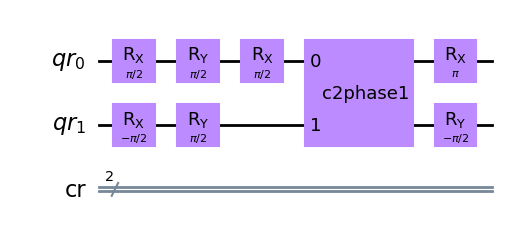

In [21]:
from qiskit.quantum_info import TwoQubitBasisDecomposer, OneQubitEulerDecomposer
from qiskit.extensions import UnitaryGate
from qiskit.quantum_info import Clifford


def get_gate_c2phase1():
    matrix = [[1, 0,  0,  0],
              [0, 1j, 0,  0],
              [0, 0,  1j, 0],
              [0, 0,  0,  1]]

    cphase = UnitaryGate(endian_big_2_little(matrix), label='c2phase1')  # available entangling gate

    return cphase

def decompose_c1not2(mode='qiskit', for_sim=False):
    if mode == 'qiskit':
        return _decompose_c1not2_qiskit_fix()
    elif mode == 'ferlemann':
        return _decompose_c1not2_ferlemann(for_sim=for_sim)
    else:
        raise ValueError

def _decompose_c1not2_qiskit():
    # result may vary in different qiskit versions!
    # c2phase1_dd in my notation
    matrix = [[1, 0,  0,  0],
              [0, 1j, 0,  0],
              [0, 0,  1j, 0],
              [0, 0,  0,  1]]
    c2not1p = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate
    decomp_into_cphase = TwoQubitBasisDecomposer(c2not1p, euler_basis="XYX")

    # c1not2 in big endian notation (my style)
    matrix = [[1, 0, 0, 0],  
              [0, 1, 0, 0],
              [0, 0, 0, 1],
              [0, 0, 1, 0]]

    testU = UnitaryGate(endian_big_2_little(matrix))
    circ = decomp_into_cphase(testU)
    
    # change naming of basis gate
    circ.data[3][0].name = 'c2phase1'   # todo: this probably breaks the simulation
    
    return circ.data

def _decompose_c1not2_qiskit_fix():
    matrix = [[1, 0,  0,  0],
              [0, 1j, 0,  0],
              [0, 0,  1j, 0],
              [0, 0,  0,  1]]
    c2not1p = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate
    
    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs

    qc = qiskit.QuantumCircuit(*qregs, *cregs)

    qc.rx(-np.pi/4, 1)
    qc.ry(-np.pi/2, 1)

    qc.unitary(c2not1p, [0,1], label='c2phase1')
    
    qc.rx(np.pi/2, 0)
    qc.ry(np.pi/2, 0)
    qc.rx(-np.pi/2, 0)
    
    qc.ry(np.pi/2, 1)
    qc.rx(-np.pi/4, 1)
    
     # change naming of basis gate
    qc.data[2][0].name = 'c2phase1'
    
    
    return qc

def _decompose_c1not2_ferlemann(for_sim=False):
    """
    optimized ferlemann_v1 by qiskit decomposition
    """
    matrix = [[1, 0,  0,  0],
              [0, 1j, 0,  0],
              [0, 0,  1j, 0],
              [0, 0,  0,  1]]
    c2not1p = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate
    
    
    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs

    qc = qiskit.QuantumCircuit(*qregs, *cregs)

    qc.rx(np.pi/2, 0)
    qc.ry(np.pi/2, 0)
    qc.rx(np.pi/2, 0)

    qc.rx(-np.pi/2, 1)
    qc.ry(np.pi/2, 1)

    qc.unitary(c2not1p, [0,1], label='c2phase1')

    qc.rx(np.pi, 0)
    qc.ry(-np.pi/2, 1)
        
     # change naming of basis gate
    # seems to break simulation
    if not for_sim:
        qc.data[5][0].name = 'c2phase1'
    
    return qc

def _decompose_c1not2_ferlemann_v1():
    """
    originial decomposition as in email
    """
    matrix = [[1, 0,  0,  0],
              [0, 1j, 0,  0],
              [0, 0,  1j, 0],
              [0, 0,  0,  1]]
    c2not1p = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate
    
    
    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs

    qc = qiskit.QuantumCircuit(*qregs, *cregs)

    # swap (as Florians Emails is different basis notation)
    qc.rx(np.pi, 0)
    qc.rx(np.pi, 1)

    qc.rx(-np.pi/2, 0)
    qc.ry(np.pi/2, 0)
    qc.rx(-np.pi/2, 0)
    qc.rx(-np.pi, 0)

    qc.rx(np.pi/2, 1)
    qc.ry(np.pi/2, 1)

    qc.unitary(c2not1p, [0,1], label='c2phase1')

    qc.rx(-np.pi, 1)
    qc.ry(np.pi/2, 1)

    # swap (as Florians Emails is different basis notation)
    qc.rx(np.pi, 0)
    qc.rx(np.pi, 1)
    
        
     # change naming of basis gate
    qc.data[8][0].name = 'c2phase1'
    
    return qc


from qiskit.visualization import array_to_latex

def sim_circ(circ, filter_gate=''):
    # Create a new circuit without the measurement
    qregs = circ.qregs
    cregs = circ.cregs
    qc = qiskit.QuantumCircuit(*qregs, *cregs)
    for i in circ:
        if i[0].name == 'measure':
            continue
        if i[0].name != filter_gate:
            qc.data.append(i)

    
    sim = qiskit.Aer.get_backend('aer_simulator')
    basis_gates = ['u1','u2','u3','cx'] # use U,CX for now
    qc.save_unitary()
    unitary = sim.run(qc).result().get_unitary()
    
    return qc, unitary
    

def get_circ_rev(circ, filter_gate='', basis_gates=['rx', 'ry', 'cx'], only_cliff=True):
    

    qregs = circ.qregs
    cregs = circ.cregs
    
    _, unitary = sim_circ(circ, filter_gate=filter_gate)

    # calculate reverse circuit if needed
    qc_rev = qiskit.QuantumCircuit(*qregs, *cregs)
    unitary_rev = unitary.adjoint()
    qc_rev.unitary(unitary_rev, [0,1])
    
    gate_u = UnitaryGate(unitary_rev, label='rev') 

    if only_cliff:
        cliff_u = Clifford(gate_u)
        qc_rev_cliff = qiskit.synthesis.synth_clifford_full(cliff_u)
        qc_rev = qc_rev_cliff

    circ_rev = qiskit.compiler.transpile(qc_rev, basis_gates=basis_gates, optimization_level=0)
    
    return circ_rev, unitary_rev

def append_rev_circ(circ, basis_gates=['rx', 'ry', 'cx']):
    qregs = circ.qregs
    cregs = circ.cregs
    
    circ_rev, _ = get_circ_rev(circ, basis_gates=basis_gates)
    
    qc_tot = qiskit.QuantumCircuit(*qregs, *cregs)
    qc_rev = qiskit.QuantumCircuit(*qregs, *cregs)
    for i in circ:
        if i[0].name == 'measure':
            continue
        qc_tot.data.append(i)
    
    qc_tot.barrier([0,1])
    #qc_tot.append(qiskit.circuit.Barrier(2))  # todo: fix not correctly spanned over both qubits
    #for g_rev in circ_rev:
    #    qc_tot.data.append(g_rev)   
    #    qc_rev.data.append(g_rev) 
    
    qc_rev = qc_rev.compose(circ_rev)
    qc_tot = qc_tot.compose(qc_rev)
    
    return qc_tot, qc_rev


"""
# OLD MANUAL WAY
matrix_c1not2 = [[1, 0, 0, 0],
          [0, 1, 0, 0],
          [0, 0, 0, 1],
          [0, 0, 1, 0]]
# c2phase1_dd in my notation
matrix = [[1, 0,  0,  0],
          [0, 1j, 0,  0],
          [0, 0,  1j, 0],
          [0, 0,  0,  1]]


import scipy 

c2not1p = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate

c2not1p_x2 = UnitaryGate(np.linalg.matrix_power(c2not1p, 2))
c2not1p_2 = UnitaryGate(scipy.linalg.sqrtm(c2not1p))

decomp_into_cphase = TwoQubitBasisDecomposer(c2not1p, euler_basis="XYX")
#decomp_into_cphase = TwoQubitBasisDecomposer(qiskit.circuit.library.CXGate(), euler_basis="XYX")


# c2not1 in big endian notation (my style)
#matrix = [[1, 0, 0, 0],  
#          [0, 0, 0, 1],
#          [0, 0, 1, 0],
#          [0, 1, 0, 0]]
# c1not2 in big endian notation (my style)
matrix = [[1, 0, 0, 0],  
          [0, 1, 0, 0],
          [0, 0, 0, 1],
          [0, 0, 1, 0]]
# c2not1p in big endian notation (my style)
#matrix = [[0, 0, -1j,  0],
#          [0, 1j,  0,  0],
#          [1, 0,   0,  0],
#          [0, 0,   0,  1]]
testU = UnitaryGate(endian_big_2_little(matrix))


# Now, we decompose it using your decomposer:
circ = decomp_into_cphase(testU)
circ = decomp_into_cphase(testU)
circ.draw('mpl')
"""

# new
qregs = rb_circs[0][0].qregs
cregs = rb_circs[0][0].cregs
circ = qiskit.QuantumCircuit(*qregs, *cregs)

gates = decompose_c1not2('ferlemann', for_sim=True)
#gates = decompose_c1not2()
for gate in gates:
    circ.append(gate)

circ.draw('mpl')


In [22]:
from qiskit.visualization import array_to_latex

        
sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['u1','u2','u3','cx'] # use U,CX for now
circ.save_unitary()
unitary_tot = sim.run(circ).result().get_unitary()
array_to_latex(unitary_tot, prefix="\\text{Unitary} = ")

<IPython.core.display.Latex object>

In [23]:
unitary_tot_end = endian_big_2_little(unitary_tot)   # swap qubit order
array_to_latex(unitary_tot_end, prefix="\\text{Unitary} = ")


<IPython.core.display.Latex object>

In [269]:

def swap_basis(matrix):
    
    U = np.asarray(matrix)
    
    # Pauli-X gate
    X = np.array([[0, 1],
                  [1, 0]])

    U_swapped = np.kron(X, np.eye(2)) @ U @ np.kron(X, np.eye(2))
    U_swapped = np.kron(np.eye(2), X) @ U_swapped @ np.kron(np.eye(2), X)
    return U_swapped



unitary_tot_swap = swap_basis(unitary_tot)   # swap basis
array_to_latex(unitary_tot_swap, prefix="\\text{Unitary} = ")



NameError: name 'unitary_tot' is not defined

### via Florian decomposition 

See Email 20230914. First, we express his notation U(theta, phi) in X,Y gates.

In [118]:
qiskit.circuit.library.RYGate(np.pi/2).to_matrix()

array([[ 0.70710678+0.j, -0.70710678+0.j],
       [ 0.70710678+0.j,  0.70710678+0.j]])

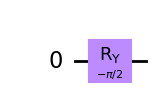

In [270]:

decomp_into_xy = OneQubitEulerDecomposer(basis="XYX")


# Florian U(pi, pi/4)
matrix = [[0, (1-1j)/np.sqrt(2)],
          [(-1-1j)/np.sqrt(2), 0]]

# Florian U(pi, 0)
matrix = [[0, -1j],
          [-1j, 0]]

# Florian U(pi/2, 0)
matrix = [[1/np.sqrt(2), -1j/np.sqrt(2)],
          [-1j/np.sqrt(2), 1/np.sqrt(2)]]

# Florian U(pi/2, pi/2)
matrix = [[1/np.sqrt(2), 1/np.sqrt(2)],
          [-1/np.sqrt(2), 1/np.sqrt(2)]]


testU = UnitaryGate(matrix)

# Now, we decompose it using your decomposer:
circ = decomp_into_xy(testU)
circ.draw('mpl')


C:\Users\Timo\AppData\Local\Temp\ipykernel_6900\1252614845.py:272: DeprecationWarning: The property ``qiskit.circuit.bit.Bit.index`` is deprecated as of qiskit-terra 0.17. It will be removed no earlier than 3 months after the release date. Instead, use :meth:`~qiskit.circuit.quantumcircuit.QuantumCircuit.find_bit` to find all the containing registers within a circuit and the index of the bit within the circuit.
  qubits = [g[1][0].index]


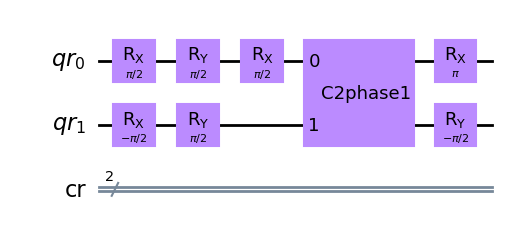

In [463]:
# optimize 
# new
qregs = rb_circs[0][0].qregs
cregs = rb_circs[0][0].cregs
circ = qiskit.QuantumCircuit(*qregs, *cregs)

circ.cx([0],[1])
qc = substitute_cnot(circ, 'ferlemann')
#qc = optimize_circ_q1(qc)

qc.draw('mpl')

In [274]:
# get unitary

sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['u1','u2','u3','cx'] # use U,CX for now
qc.save_unitary()
unitary_tot = sim.run(qc).result().get_unitary()
array_to_latex(unitary_tot, prefix="\\text{Unitary} = ")


<IPython.core.display.Latex object>

In [275]:
unitary_tot_end = endian_big_2_little(unitary_tot)
array_to_latex(unitary_tot_end, prefix="\\text{Unitary} = ")


<IPython.core.display.Latex object>

In [186]:
qregs = rb_circs[0][0].qregs
cregs = rb_circs[0][0].cregs

circ = qiskit.QuantumCircuit(*qregs, *cregs)
circ.rx(np.pi/2, 0)
circ.rx(np.pi, 1)
#circ.draw()

In [187]:
sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['u1','u2','u3','cx'] # use U,CX for now
#circ.save_unitary()
#circ.save_statevector()
circ.save_density_matrix()
#unitary_tot = sim.run(circ).result().get_unitary()
#state_out = sim.run(circ).result().get_statevector()
state_out = sim.run(circ).result()
state_out = state_out.results[0].data.density_matrix

#array_to_latex(unitary_tot, prefix="\\text{Unitary} = ")
array_to_latex(state_out, prefix="\\text{Unitary} = ")

INFO:qiskit.compiler.assembler:Total Assembly Time - 0.00000 (ms)


<IPython.core.display.Latex object>

## Transpile gate set
The defualt gate set used is by qiskit convention (X,Y,Sdg,H,CX). We transpile to a somewhat more useful gate set for NV experiment (1, pi2_x, pi2_y, CNOT).

### Custom c2not1 p transpile target
TODO: Not working right now! Instea, transpile to c1not2 and use explicit decomposition later.
Create a transpile target with our available c2not1 gate


In [45]:
from qiskit.transpiler import Target, InstructionProperties, CouplingMap
from qiskit.circuit.library import RXGate, RYGate, CXGate
from qiskit.circuit import Parameter
from qiskit.extensions import UnitaryGate
from qiskit.transpiler.timing_constraints import TimingConstraints

nv_cmap = CouplingMap([(0, 1), (1, 0)])
theta = Parameter('theta')
nv_target = Target(num_qubits=2, dt=1e-10)

rx_props = {
    (0,): InstructionProperties(duration=50e-9, error=0.00),
}
cnot_props = {
    (0,1): InstructionProperties(duration=5000e-9, error=0.00),
}

nv_target.add_instruction(RXGate(theta), rx_props)
nv_target.add_instruction(RYGate(theta), rx_props)

matrix =  [[0, 0,  1j, 0],
          [0,  0,  0,  1],
          [-1, 0,  0,  0],
          [0, -1j, 0,  0]]
cphase = UnitaryGate(endian_big_2_little(matrix))  # available entangling gate
nv_target.add_instruction(cphase, cnot_props, name='c2phase1')



nv_target.instructions
nv_target.operation_names
#nv_target.get_non_global_operation_names()



dict_keys(['rx', 'ry', 'c2phase1'])

### Transpile to c1not2, rx, ry

First transpile into a gate set (rx, ry, c1not2) that works well with qiskit. Then, replace the c1not2 by a circuit that uses our c2not1_p gate available in the experiment.

In [33]:
transpile_to_nv = True   # replace CNOT by available Cphase in NV
#transpile_to_nv = False
params['strip_cnot'] = False
native_gates = ['rx', 'ry', 'cx']

rb_circs_native =  []
for circ_list in rb_circs:
    rb_i = []
    for circ_in in circ_list:
        circ_t = transpile(circ_in, basis_gates=native_gates) #['rx', 'rz', 'ry', 'cx']
        #circ_t = transpile(circ_in, basis_gates=['rx, ry', 'c2phase1'], target=nv_target, coupling_map=nv_cmap) 
        
        if transpile_to_nv:
            rb_i.append(substitute_cnot(circ_t, 'ferlemann'))
            #rb_i.append(substitute_cnot(circ_t))
        else:
            rb_i.append(circ_t)
        
        # filter out any gate with free evolution
        #steps_q0, steps_q1 = circuit_2_step_list(circ_t, qubit_idx=0, swap_qubits=True), circuit_2_step_list(circ_t, qubit_idx=1, swap_qubits=True)
        #ser_gate_list = serialize_step_list(steps_q0, steps_q1)
        #if not _has_id_gate(ser_gate_list):
        #    rb_i.append(circ_t)
        
    rb_circs_native.append(cp.deepcopy(rb_i))

C:\Users\Timo\AppData\Local\Temp\ipykernel_12632\3308953529.py:282: DeprecationWarning: Back-references to from Bit instances to their containing Registers have been deprecated. Instead, inspect Registers to find their contained Bits.
  qubits = [g[1][0].index]


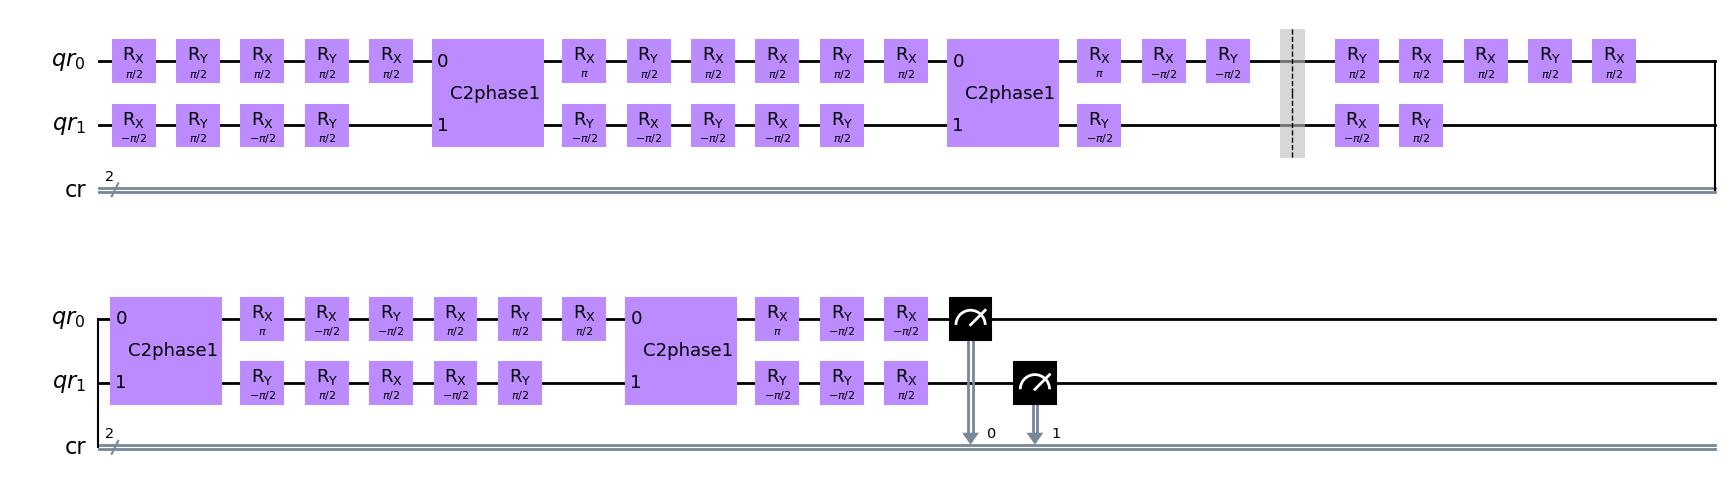

In [10]:
idx_cliff, idx_rand = 0, 2
circ = rb_circs_native[idx_cliff][idx_rand]
circ.draw(output='mpl')


### Optimize 1Q gates

In [34]:


#target = custom_target  # None
target = None  # free optimization, also allowing parametrized gates

qudi_gates_opt = []

#for idx_cliff, circs in enumerate(qudi_gates):   # for loaded fates (fast)
for idx_cliff, circs in enumerate(rb_circs_native):
    qudi_circs = []
    for idx_rand, qc in enumerate(circs):
        
        qc_opt = optimize_circ_q1(qc)
        
        qudi_circs.append(qc_opt)
    
    qudi_gates_opt.append(qudi_circs)



In [39]:
rb_circs_native = qudi_gates_opt

## Manipulate 

Eg. remove all cnots for debugging

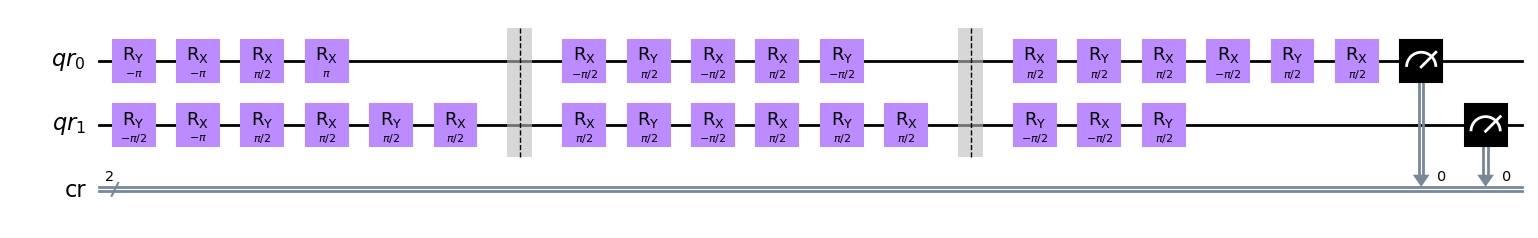

In [45]:
idx_cliff, idx_rand = 1, 3 # for plotting only

params['clip_n_gates'] = False
params['strip_cnot'] = True

if params['strip_cnot']:
    rb_circs_native = filter_gate(rb_circs_native, 'cx')
    rb_circs_native = filter_gate(rb_circs_native, 'c2phase1')
    
circ = rb_circs_native[idx_cliff][idx_rand]
circ.draw(output='mpl')

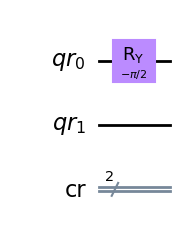

In [125]:

params['clip_n_gates'] = 0.2

if params['clip_n_gates']:
    rb_circs_native = clip_n_gates(rb_circs_native, params['clip_n_gates'])


circ = rb_circs_native[idx_cliff][idx_rand]
circ.draw(output='mpl')

## Make interleaved 

In [86]:
# Todo: Atm, interleaving Cphase (no clifford) or CNOT (clifford) both leads to reverse circuits with pi4s or even worse

Instruction(name='c2phase1', num_qubits=2, num_clbits=0, params=[array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+1.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]])])

'ry90_on1'

C:\Users\Timo\AppData\Local\Temp\ipykernel_25512\1252614845.py:272: DeprecationWarning: The property ``qiskit.circuit.bit.Bit.index`` is deprecated as of qiskit-terra 0.17. It will be removed no earlier than 3 months after the release date. Instead, use :meth:`~qiskit.circuit.quantumcircuit.QuantumCircuit.find_bit` to find all the containing registers within a circuit and the index of the bit within the circuit.
  qubits = [g[1][0].index]


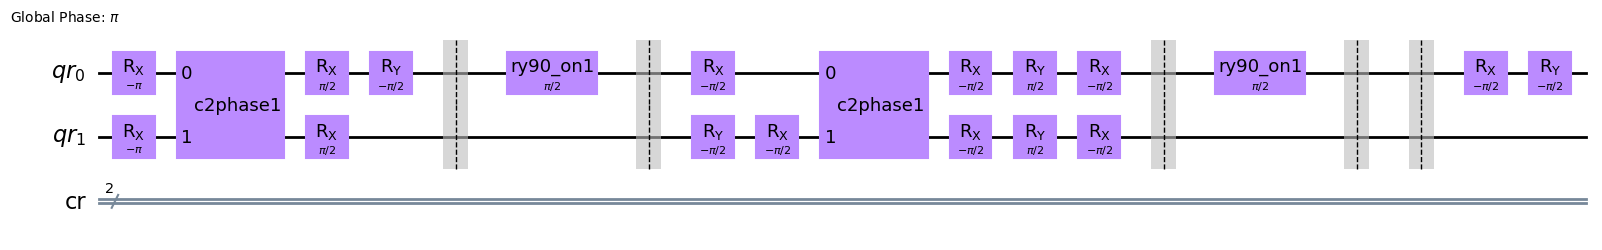

In [92]:
idx_cliff, idx_rand = 0, 2 # for plotting only

def make_interleaved(rb_circs, gate_dut_func, qubits):
    
    rb_circs_native = rb_circs
    
    transpile_to_nv = True   # replace CNOT by available Cphase in NV
    reverse_to_ground = True
    optimize_1qs = True

    circ = rb_circs_native[0][0]
    qregs = circ.qregs
    cregs = circ.cregs

    params['interleaved_rb'] = gate_dut_func().label

    # inteleave after each clifford step the gate under test
    rb_circs_i, rev_circs = [], []

    unitaries_rev = []

    for circ_list in rb_circs_native:
        rb_i, rev_i = [], []
        rev_u_i  =[]

        for circ_in in circ_list:
            qc = qiskit.QuantumCircuit(*qregs, *cregs)

            for idx_g, gate in enumerate(circ_in):
                #print(f"{gate}")
                is_last = (idx_g == len(circ_in)-1)
                if gate[0].name == 'barrier':
                    qc.append(gate)
                    qubits = gate_dut_qubits
                    #qc.append(gate_dut_func(), qubits)
                    qc.append(gate_dut_func(), qubits)
                    qc.append(gate)
                elif gate[0].name == 'measure':
                    pass
                else:
                    qc.append(gate)
                if is_last:
                    qubits = gate_dut_qubits
                    #qc.append(gate)
                    qc.barrier()
                    qc.append(gate_dut_func(), qubits)


            qc.barrier()
            circ_rev = qiskit.QuantumCircuit(*qregs, *cregs)

            if reverse_to_ground:
                #_, u_i = get_circ_rev(qc, only_cliff=True)
                qc, circ_rev  = append_rev_circ(qc)           

            if transpile_to_nv:
                qc = substitute_cnot(qc, 'ferlemann')
                circ_rev = substitute_cnot(circ_rev, 'ferlemann')
            if optimize_1qs:
                qc = optimize_circ_q1(qc)
                circ_rev = optimize_circ_q1(circ_rev)

            rb_i.append(qc)
            rev_i.append(circ_rev)
            #rev_u_i.append(u_i)

        rev_circs.append(rev_i) 
        rb_circs_i.append(cp.deepcopy(rb_i))
    #unitaries_rev.append(rev_u_i)
    
    return rb_circs_i, rev_circs
        

gate_dut_qubits = [0,1]
gate_dut_func = get_gate_c2phase1
#gate_dut_func =  lambda: qiskit.circuit.library.CXGate()
gate_dut_qubits = [0]
#gate_dut_func =  lambda: qiskit.circuit.library.RXGate(np.pi/2, label='rx90_on1')
gate_dut_func =  lambda: qiskit.circuit.library.RYGate(np.pi/2, label='ry90_on1')
#gate_dut_qubits = [1]
#gate_dut_func =  lambda: qiskit.circuit.library.RXGate(np.pi/2, label='rx90_on1')
#gate_dut_func =  lambda: qiskit.circuit.library.RYGate(np.pi/2, label='ry90_on1')


rb_circs_i, rev_circs = make_interleaved(rb_circs_native, gate_dut_func, gate_dut_qubits)       
#rb_circs[2][2].draw('mpl')
#qc_rev = rb_circs_i[idx_cliff][idx_rand]
rb_circs_i[idx_cliff][idx_rand].draw('mpl')
#rev_circs[idx_cliff][idx_rand].draw('mpl')



In [83]:
params['interleaved_rb'] 

'ry90_on1'

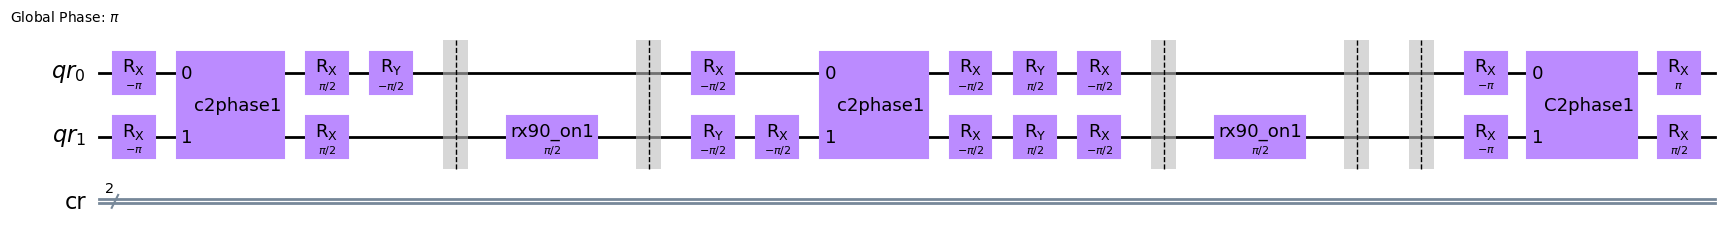

In [72]:
rb_circs_i[idx_cliff][idx_rand].draw('mpl')

In [743]:
params['interleaved_rb'], calc_1q_rot_angles(rev_circs, ignore_rots=[0.5, 1.0])



('unitary', [])

In [35]:
# Set as native RBs to save
rb_circs_native = rb_circs_i

### Batched 

In [119]:

duts = [(lambda: qiskit.circuit.library.RXGate(np.pi/2, label='rx90_on1'),[0]),
        (lambda: qiskit.circuit.library.RYGate(np.pi/2, label='ry90_on1'),[0]),
        (lambda: qiskit.circuit.library.RXGate(np.pi, label='rx180_on1'),[0]),
        (lambda: qiskit.circuit.library.RYGate(np.pi, label='ry180_on1'),[0]),
        (lambda: qiskit.circuit.library.RXGate(np.pi/2, label='rx90_on2'),[1]),
        (lambda: qiskit.circuit.library.RYGate(np.pi/2, label='ry90_on2'),[1]),
        (lambda: qiskit.circuit.library.RXGate(np.pi, label='rx180_on2'),[1]),
        (lambda: qiskit.circuit.library.RYGate(np.pi, label='ry180_on2'),[1])]

rb_circs_i = []
for idx, (dut, qubits) in enumerate(duts):
    rb_i, rev_circs = make_interleaved(rb_circs_native, dut, qubits)
            
    qudi_gates_i = rb_2_qudi_gates(rb_i)
    
    #fname = get_save_fname()
    fname = f"20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs_interleave={dut().label}.json"
    
    save_to_file(fname, qudi_gates_i)




C:\Users\Timo\AppData\Local\Temp\ipykernel_25512\1252614845.py:272: DeprecationWarning: The property ``qiskit.circuit.bit.Bit.index`` is deprecated as of qiskit-terra 0.17. It will be removed no earlier than 3 months after the release date. Instead, use :meth:`~qiskit.circuit.quantumcircuit.QuantumCircuit.find_bit` to find all the containing registers within a circuit and the index of the bit within the circuit.
  qubits = [g[1][0].index]


In [117]:
qudi_gates_i

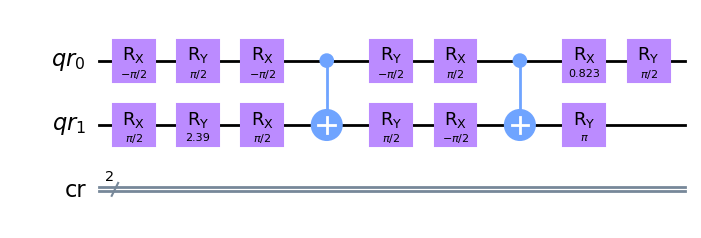

In [250]:
# not working - play around with custom transpile target

custom_target = Target()
dummy_error_1q = None
"""
gateset_rots = [ 0.5, 1., -0.5, -1.,]
gateset_phis_deg = [0, 90]
gateset_qubits = [(0,), (1,)]

for rot in gateset_rots:
    for phi in gateset_phis_deg:
        for qubit in gateset_qubits:
            rx_props = {
                qubit: InstructionProperties(error=dummy_error_1q)
            }
            if phi == 0:
                gate = RXGate(rot*math.pi)
            elif phi == 90:
                gate = RYGate(rot*math.pi)
            custom_target.add_instruction(gate, rx_props, name=f'r{phi}deg_on={qubit}_{rot}')

"""


qregs = circ.qregs
cregs = circ.cregs

_, unitary = sim_circ(circ, filter_gate=filter_gate)

# calculate reverse circuit if needed

basis_gates=['rx', 'ry', 'cx']
circ_rev = qiskit.compiler.transpile(qc_rev, basis_gates=basis_gates, optimization_level=3)

circ_rev.draw('mpl')

## Add reverse circuit
If the rb sequence was manipulated (eg. by filtering out CNOTs), it's not guaranteed that we return to the ground state. Append gates to enforce return to ground state.

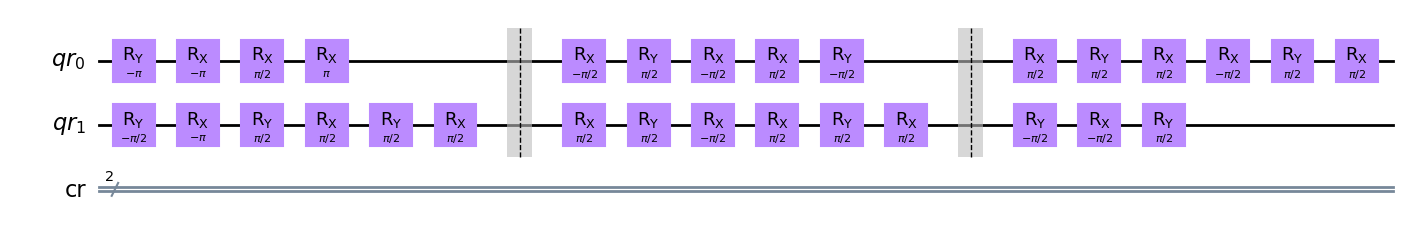

In [46]:
#idx_cliff, idx_rand = 0, 1 # for plotting only


rb_circs_rev = []
for circ_list in rb_circs_native:
    rb_i = []
    for circ_in in circ_list:
        circ_t, _ = append_rev_circ(circ_in)
        rb_i.append(circ_t)
        
    rb_circs_rev.append(cp.deepcopy(rb_i))
        

#rb_circs[2][2].draw('mpl')
rb_circs_rev[idx_cliff][idx_rand].draw('mpl')

Overwrite the circuit to save with the manipulated, reversed circuit.

In [47]:
rb_circs_native = rb_circs_rev

## Calc (native) gates per clifford length

In [146]:
native_gates

['rx', 'ry', 'cx']

In [11]:
def calc_1q(rb_circs, basis_gates=['ry', 'rx']):
    # calculate number of cnots per xdata step
    arr = np.zeros((len(rb_circs),len(rb_circs[0])))
    for i in range(0, len(rb_circs)):
        for j in range(0, len(rb_circs[0])):
            arr[i,j] = get_n_1q_rot(rb_circs[i][j], basis_gates=basis_gates)
    return arr

def get_n_cx(circ):
    if type(circ) == list:
        # after conversion to qudi format
        return np.sum([el[0][0]=='cx' for el in circ[1]])
    
    return np.sum([el[0].name=='cx' for el in circ.data])

def get_n_1q_rot(circ, basis_gates=['ry', 'rx']):
    if type(circ) == list:
        # after conversion to qudi format
        return np.sum([el[0][0] in basis_gates for el in circ[1]])
    
    elif type(circ) == qiskit.circuit.quantumcircuit.QuantumCircuit:
        return np.sum([el[0].name in basis_gates for el in circ.data])

    raise ValueError 
    
def decay_2_epc(tau_decay, dtau=0, n_qubits=1):
    # shaddows PostProcess_qudiplotter
    alpha = np.exp(-1/(tau_decay))
    d_alpha = np.exp(-1/(tau_decay))*1/(tau_decay)**2*dtau # todo: is linear error propagation clever for this transformation?

    epc = (2**(n_qubits)-1)/(2**n_qubits)*(1-alpha)
    d_epc = (2**(n_qubits)-1)/2**n_qubits*(d_alpha)
    
    info_dict = {}
    info_dict['d_epc'] = d_epc
    info_dict['alpha'] = alpha
    info_dict['d_alpha'] = d_alpha
             
    return epc, info_dict

0

0

In [40]:
rb_to_analyze = rb_circs_native
#rb_to_analyze = qudi_gates


clif_length_vector = rb_opts['length_vector']
n1q_pg = calc_1q(rb_to_analyze, basis_gates=['rx', 'ry'])
n2q = calc_1q(rb_to_analyze, basis_gates=['cx', 'c2phase1'])


# count mean per idx_cliff
n1q =  np.mean(n1q_pg, axis=1)
n2q = np.mean(n2q, axis=1)

n1q_per_cliff = np.asarray(n1q)/np.asarray(clif_length_vector)
n2q_per_cliff = np.asarray(n2q)/np.asarray(clif_length_vector)
np.mean(n1q_per_cliff)
f"native 1Q gates per clifford per qubit= {np.mean(n1q_per_cliff)/params['n_qubits']:.2f}, {n1q}/{clif_length_vector}"\
f"native 1Q gates per clifford= {np.mean(n1q_per_cliff):.2f}"\
f"native 2Q gates per clifford (both qubits)= {np.mean(n2q_per_cliff):.2f}, {n2q}/{clif_length_vector}"


'native 1Q gates per clifford per qubit= 4.33, [ 16.58  25.1   32.84  40.94  50.2   57.94  65.2   74.12  83.36  91.98\n 100.06 108.56 116.92 124.42 133.8  142.2  149.98 157.08 165.82 174.36\n 182.42 190.52 199.18 207.44 216.38 224.88 233.36 241.6  248.72 256.46\n 265.44 272.94 280.24 289.74 297.62 304.66 313.56 321.26 329.88 336.84\n 345.56 353.88 362.56 370.58 378.48 387.06 394.56 401.96 410.02 418.2\n 426.5  435.02 441.84 450.9  458.48 466.68 474.2  483.56 491.86 498.62\n 507.18 515.06 522.32 531.48 539.42 548.5  554.94 563.38 571.76 579.92\n 587.6  595.9  604.36 612.66 620.7  628.58 637.28 644.84 652.78 660.98\n 669.18 677.4  684.74 693.12 700.54 708.74 717.84 725.76 734.66 741.64\n 750.02 758.32 766.76 775.14 783.2  792.42 799.54 807.16 815.32]/[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 6

## Calculate fidelities: EPC to EPG

In [2]:
import qiskit.ignis.verification.randomized_benchmarking.rb_utils as rb_utils
import qiskit.ignis.verification as rb_verif

C:\Users\Timo\AppData\Local\Temp\ipykernel_29228\1976001002.py:1: DeprecationWarning: The qiskit.ignis package is deprecated and has been supersceded by the qiskit-experiments project. Refer to the migration guide: https://github.com/Qiskit/qiskit-ignis#migration-guide on how to migrate to the new project.
  import qiskit.ignis.verification.randomized_benchmarking.rb_utils as rb_utils


In [94]:
# new, without qiskit and number of 1q gates
# solely from EPC definition

def estimate_epg_2q(epc_2q, epc_2q_nocnot, n2q_per_cliff=1.8):
    # (1-EPC_mes) = (1-EPG_1q)^n1q* (1-EPG_2q)^n2q
    # (1-EPG_1q)^n1q == (1-EPC_1q)

    return 1 - np.power((1-epc_2q)/(1-epc_2q_nocnot), 1/n2q_per_cliff)


epc_mes = 1.69e-1  # data 20231017
epc_mes = 14.96e-2 # data 20231201 swapped NVs
depc_mes = 2.72e-2  # data 20231201 swapped NVs
# error bounds
#epc_mes = epc_mes + depc_mes

# EPC from mes
# TODO: for lifetime -> EPC: 2^n/2^n-1  with n=1 or n=2
# 1q fidelity from 2Q_noCNOT to include free evolution
epc_2q_nocnot = 0.0782  # ??
epc_2q_nocnot = 8.467e-2   # 20231202, swappedNV
depc_2q_nocnot = 1.312e-2   # 20231202, swappedNV


gpc = {0: {'cx': 1.8, 'u1': 10.53/2}}

epg_cphase = estimate_epg_2q(epc_mes, epc_2q_nocnot, gpc[0]['cx'])
# error bound to left and right
# in theory could be assymetric, but turns out to be very close to each other
epg_cphase_d2 = estimate_epg_2q(epc_mes+depc_mes, epc_2q_nocnot-depc_2q_nocnot, gpc[0]['cx'])
epg_cphase_d1 = estimate_epg_2q(epc_mes-depc_mes, epc_2q_nocnot+depc_2q_nocnot, gpc[0]['cx'])

depg_cphase = np.mean([abs(epg_cphase_d1-epg_cphase), abs(epg_cphase_d2-epg_cphase)])

epg_cphase, depg_cphase

(0.040052392612071164, 0.024705350145139637)

In [64]:
# OLD


# Calc 2Q EPC from given epg_cphase and EPC_noCNOT / EPC_1Q
# Iteratively choose epg_cphase to match measured 2Q EPC
# https://qiskit.org/documentation/stable/0.24/stubs/qiskit.ignis.verification.calculate_2q_epc.html#qiskit.ignis.verification.calculate_2q_epc
epc_mes = 1.69e-1  # data 20231017
epc_mes = 14.96e-2 # data 20231201 swapped NVs
depc_mes = 2.7e-2  
# error bounds
#epc_mes = epc_mes + depc_mes


# TODO: splitting EPG(2Q_noCNOT) on 2 qubits (10.5/2) yields slightly different results 
# than average fidelity from 10.5 native gates

epg_cphase_guess = 0.061
#epg_cphase = 0.08
#epg_cphase = 0.041

# EPC from mes
# 1q fidelity from 2Q_noCNOT to include free evolution
epc_2q_nocnot = 0.0782  # ??
epc_2q_nocnot = 8.44e-2   # 20231202, swappedNV



# gate counts of 2Q RB experiment
gpc_2q_nocnot = 11.51   # total, not per qubit
# distribute total 1q gate count to "per qubit"
gpc = {0: {'cx': 1.8, 'u1': 10.53/2}}
gpc[1] =  {'cx': gpc[0]['cx'], 'u1': gpc[0]['u1']}


epgs_q0 = {'u1': epc_2q_nocnot/(2*gpc_2q_nocnot)}
epgs_q1 = {'u1': epc_2q_nocnot/(2*gpc_2q_nocnot)}


# EPGs estimated T2 limit
#epgs_q0 = {'u1': 9.6e-5}
#epgs_q1 = {'u1': 9.6e-5}
#epg_cphase = 0.018

def calc_epg_2q_2_epc(epg_2q, epgs_q0, epgs_q1, gpc):
    # calculate EPC according to the definition
    fid = 1
    for qubit in (0, 1):
        for epgs in (epgs_q0, epgs_q1):
            for gate, val in epgs.items():
                fid *= (1 - val) ** gpc[qubit][gate]
    fid *= (1 - epg_cphase) ** gpc[0]['cx']
    epc = 1 - fid
    
    return epc



epcs, epcs_only_2q = [], []
epgs = np.linspace(0.0, 4*epg_cphase_guess, 1000)
for epg_cphase in epgs:
    # calculate 2Q EPC
    epc_2q = rb_utils.calculate_2q_epc(
        gate_per_cliff=gpc,
        epg_2q=epg_cphase,
        qubit_pair=[0, 1],
        list_epgs_1q=[epgs_q0, epgs_q1])

    epcs.append(calc_epg_2q_2_epc(epg_cphase, epgs_q0, epgs_q1, gpc))
    epcs_only_2q.append(epc_2q)

idx_opt = np.argmin(abs(np.asarray(epcs)-epc_mes))
    
epc = epcs[idx_opt]
epg_cphase = epgs[idx_opt]

epcs_only_2q = epcs_only_2q[idx_opt]
epc_2q_2 = 1-((1 - epg_cphase) ** gpc[0]['cx'])  # only 2q part in epc


print(f"Total sequence EPC: {epc:.3f} from EPG_Cphase= {epg_cphase:.3f}, 2Q gate contribution: {epcs_only_2q:.3f} / {epc_2q_2:.3f}")


Total sequence EPC: 0.150 from EPG_Cphase= 0.046, 2Q gate contribution: 0.121 / 0.081


0.0402096682546752

In [206]:
# qiskit example: https://qiskit.org/documentation/stable/0.19/stubs/qiskit.ignis.verification.calculate_2q_epg.html
# assuming we ran 1Q RB experiment for qubit 0 and qubit 1
gpc = {0: {'cx': 0, 'u1': 0.13, 'u2': 0.31, 'u3': 0.51},
       1: {'cx': 0, 'u1': 0.10, 'u2': 0.33, 'u3': 0.51}}
epc_q0 = 1.5e-3
epc_q1 = 5.8e-4

# calculate 1Q EPGs
epgs_q0 = rb_utils.calculate_1q_epg(gate_per_cliff=gpc, epc_1q=epc_q0, qubit=0)
epgs_q1 = rb_utils.calculate_1q_epg(gate_per_cliff=gpc, epc_1q=epc_q1, qubit=1)

# assuming we ran 2Q RB experiment for qubit 0 and qubit 1
gpc = {0: {'cx': 1.49, 'u1': 0.25, 'u2': 0.95, 'u3': 0.56},
       1: {'cx': 1.49, 'u1': 0.24, 'u2': 0.98, 'u3': 0.49}}
epc = 2.4e-2

epgs_q0

{'u1': 0, 'u2': 0.0011278195488721805, 'u3': 0.002255639097744361}

In [280]:
tau_decay = 1.17#0.66
tau_decay = 0.66
#tau_decay = 1.52
tau_decay = 2.8
#tau_decay = 9.8

gpc_1q_total = 10.53
gpc_2q_total = 1.83
gpc_1q_total_nocnot = 11.51

epc_2q, _ = decay_2_epc(tau_decay, n_qubits=2)
epc_1q, _ = decay_2_epc(tau_decay, n_qubits=1)


# TODO:
# Don't understand: If setting same decay for 2Q no CNOT (-> 1Q Error) and 2Q experiment
# 2Q EPG_Comp should be 0

# for uncorrected EPG, number of 1Q gates doesn't play a role
gpc = {0: {'cx': gpc_2q_total, 'u1': gpc_1q_total},
       1: {'cx': gpc_2q_total, 'u1': gpc_1q_total}}

# to estimate 1Q errors by zeroing the epg_2q_comp
#gpc = {0: {'cx': gpc_2q_total, 'u1': gpc_1q_total_nocnot},
#       1: {'cx': gpc_2q_total, 'u1': gpc_1q_total_nocnot}}

epc = epc_2q

epgs_q0 = {'u1': 0.0064}
epgs_q1 = {'u1': 0.0064}
epgs_q0 = {'u1': 0.0042}
epgs_q1 = {'u1': 0.0042}

# calculate 2Q EPG
epg_no_comp = rb_utils.calculate_2q_epg(
    gate_per_cliff=gpc,
    epc_2q=epc,
    qubit_pair=[0, 1])

epg_comp = rb_utils.calculate_2q_epg(
    gate_per_cliff=gpc,
    epc_2q=epc,
    qubit_pair=[0, 1],
    list_epgs_1q=[epgs_q0, epgs_q1])

epc_1q, epc_1q/gpc_1q_total_nocnot
epc_2q, epg_no_comp, epg_comp


(0.22524559696865223, 0.12308502566593017, 0.07960810595434425)

### T2 coherence limit

T2 from 20230 (60G, XY8 order sweep, tau1= 800 ns):
- A: (430+-60) us
- B: (460 +- 60) us


20230922 (100G, XY8 order sweep, tau1= 800 ns):
- A: (510 +- 60) us
- B: (310 +- 40) us

In [193]:
order_xy8*8*(t_pi+t_cphase_tau1)

6.6799999999999996e-06

In [21]:
# error per 2q gate

t_pi = 1/22e6/2
t2 = [430e-6, 460e-6]
t_cphase_tau1 = 800e-9
order_xy8 = 1

epg_2q = rb_verif.coherence_limit(2, T1_list=[5000e-6, 5000e-6], T2_list=t2,
                                          gatelen=order_xy8*(t_pi+t_cphase_tau1))
epg_2q = rb_verif.coherence_limit(2, T1_list=[5000e-6, 5000e-6], T2_list=t2,
                                          gatelen=order_xy8*8*(t_pi+t_cphase_tau1))
epg_1q = rb_verif.coherence_limit(2, T1_list=[5000e-6, 5000e-6], T2_list=t2,
                                          gatelen=(t_pi))
epg_1q = rb_verif.coherence_limit(1, T1_list=[5000e-6], T2_list=t2[0:1],
                                    gatelen=(t_pi))

epg_1q, epg_2q

(1.8375149324845186e-05, 0.0122376571682494)

In [23]:
# error per clifford

# distribute total 1q gate count to "per qubit"
gpc = {0: {'cx': 1.8, 'u1': 10.53/2},
       1: {'cx': 1.8, 'u1': 10.53/2}}

# EPGs estimated T2 limit
epgs_q0 = {'u1': epg_1q}
epgs_q1 = {'u1': epg_1q}
epg_cphase = epg_2q

# calculate 2Q EPC
epc_2q = rb_utils.calculate_2q_epc(
    gate_per_cliff=gpc,
    epg_2q=epg_cphase,
    qubit_pair=[0, 1],
    list_epgs_1q=[epgs_q0, epgs_q1])

epc_2q

0.022109235363060864

## Simulate

In [ ]:
# TODO: Seems broken for transpiled circuits including c2phase1!

In [121]:
len(rb_circs_orig), len(rb_circs_orig[0])

(2, 9)

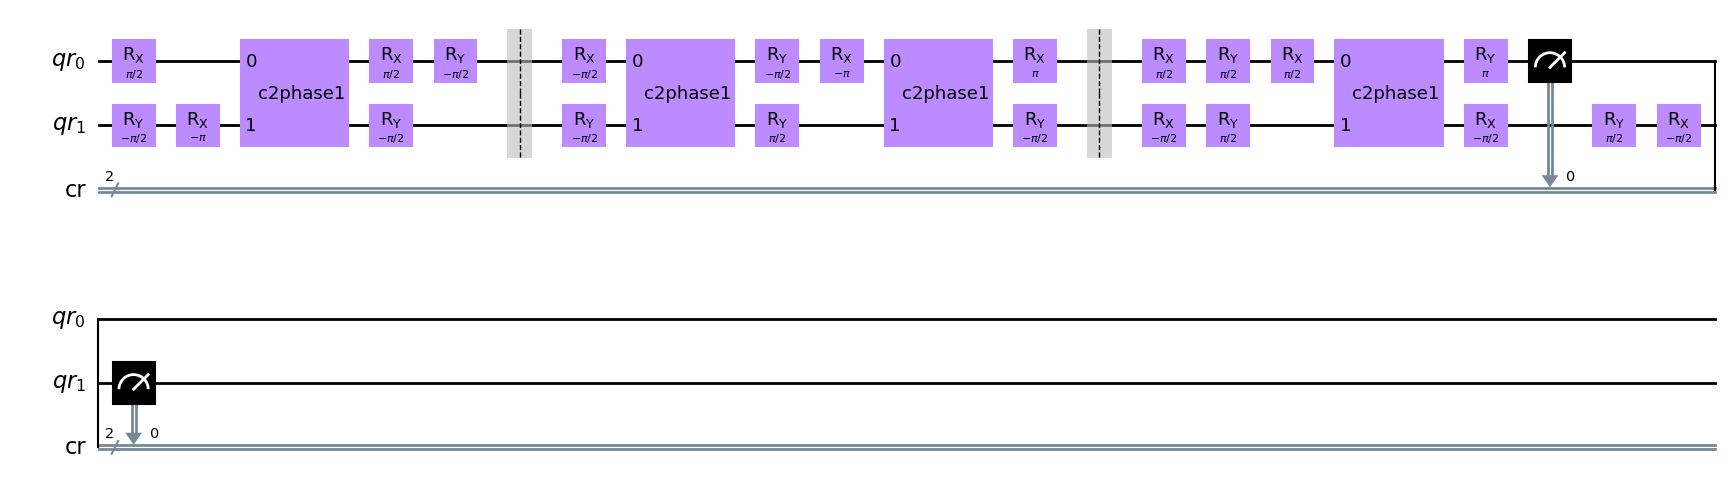

In [124]:

idx_ncliff = 1  # note that rb_circs_orig has transposed indexing
idx_rand = 0

rb_circs_native[idx_ncliff][idx_rand].draw('mpl')
#rb_circs_orig[idx_ncliff][idx_rand].draw('mpl')

In [125]:


#idx_ncliff = 4  # note that rb_circs_orig has transposed indexing
#idx_rand = 1
no_cx = False
filt_gate = 'cx' if no_cx else ''

# simultaion of original circuit
qc, unitary = sim_circ(rb_circs_orig[idx_rand][idx_ncliff], filter_gate=filt_gate)

# transpiled
qc, unitary = sim_circ(rb_circs_native[idx_ncliff][idx_rand], filter_gate=filt_gate)


# with added reversal
#rb_circs_no_cnot = filter_gate(rb_circs, 'cx')
#circ_sim, _ = append_rev_circ(rb_circs_no_cnot[idx_cliff][idx_rand])
#circ_sim = rb_circs_no_cnot[idx_cliff][idx_rand]
#qc, unitary = sim_circ(circ_sim)


array_to_latex(unitary, prefix="\\text{Unitary} = ")
#qc.draw('mpl')

<IPython.core.display.Latex object>

In [127]:
# this is the unitary needed to reverse
circ_rev, unitary_rev = get_circ_rev(rb_circs_orig[idx_rand][idx_ncliff], filter_gate=filt_gate)
array_to_latex(unitary_rev, prefix="\\text{Unitary} = ")

<IPython.core.display.Latex object>

Normally, all RB sequences come back to ground state. If we perform maniupulations (like leaving CNOTs) we have to add compensation pulses to come back at the ground state.

In [488]:
# Run simulation again with appended revese circuit
qregs = rb_circs_orig[idx_rand][idx_ncliff].qregs
cregs = rb_circs_orig[idx_rand][idx_ncliff].cregs
qc_tot = qiskit.QuantumCircuit(*qregs, *cregs)


for i in rb_circs_orig[idx_rand][idx_ncliff][0:-params['n_qubits']]:
    if no_cx:
        if i[0].name != 'cx':
            qc_tot.data.append(i)
    else:
        qc_tot.data.append(i)

for g_rev in circ_rev:
    qc_tot.data.append(g_rev)   
        
sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['u1','u2','u3','cx'] # use U,CX for now
qc_tot.save_unitary()
unitary_tot = sim.run(qc_tot).result().get_unitary()

qc_tot.draw()
array_to_latex(unitary_tot, prefix="\\text{Unitary} = ")

<IPython.core.display.Latex object>

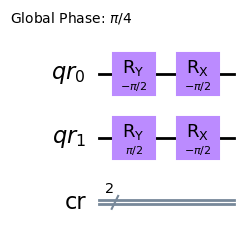

In [610]:
circ_rev.draw('mpl')

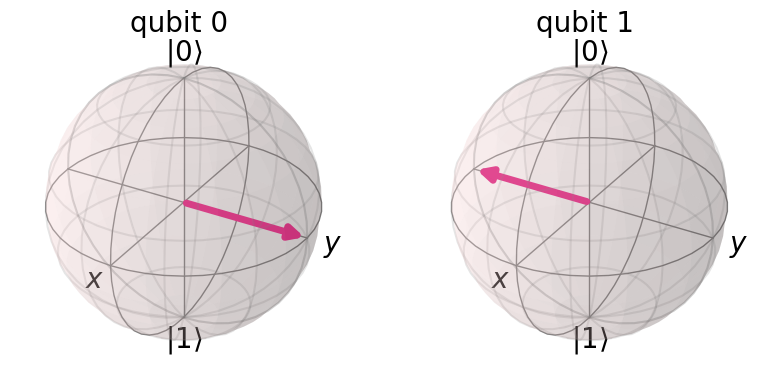

In [417]:
# effect of simulated unitary (without reversal)
from qiskit.quantum_info.states.statevector import Statevector

state_0 = Statevector([1,0,0,0])
state_out = Statevector(unitary.data.dot(state_0.data))
state_out.draw('bloch')

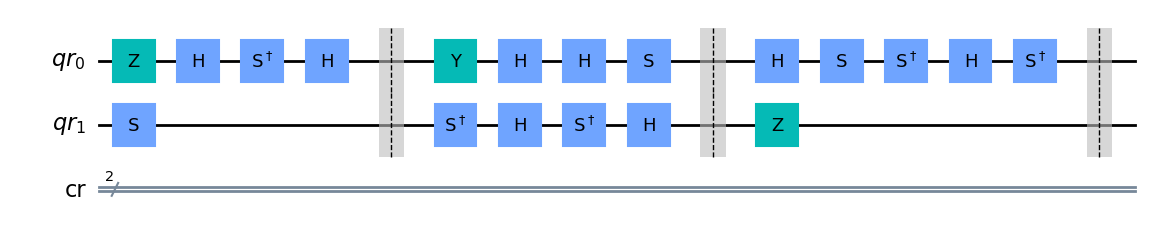

In [418]:
qc.draw('mpl')

In [8]:
# Run on a noisy simulator
noise_model = NoiseModel()

# Depolarizing error on the gates u2, u3 and cx (assuming the u1 is virtual-Z gate and no error)
p1Q = 0.01 # 0.01
p2Q = 0.03

noise_model.add_all_qubit_quantum_error(depolarizing_error(p1Q, 1), 'u2')
noise_model.add_all_qubit_quantum_error(depolarizing_error(2 * p1Q, 1), 'u3')
noise_model.add_all_qubit_quantum_error(depolarizing_error(p2Q, 2), 'cx')

backend = qiskit.Aer.get_backend('aer_simulator')

# Create the RB fitter
backend = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['u1','u2','u3','cx'] 
shots = 5
transpiled_circs_list = []
rb_fit = rb.RBFitter(None, xdata, rb_opts['rb_pattern'])
for rb_seed, rb_circ_seed in enumerate(rb_circs_orig):
    #print(f'Compiling seed {rb_seed}')
    new_rb_circ_seed = qiskit.compiler.transpile(rb_circ_seed, basis_gates=basis_gates)
    transpiled_circs_list.append(new_rb_circ_seed)
    #print(f'Simulating seed {rb_seed}')
    qobj = assemble(new_rb_circ_seed, shots=shots)
    job = backend.run(qobj,
                      noise_model=noise_model,
                      max_parallel_experiments=0)
    # Add data to the fitter
    rb_fit.add_data(job.result())
    #print('After seed %d, alpha: %f, EPC: %f'%(rb_seed,rb_fit.fit[0]['params'][1], rb_fit.fit[0]['epc']))
    
plt.figure(figsize=(8, 6))
ax = plt.subplot(1, 1, 1)

# Plot the essence by calling plot_rb_data
rb_fit.plot_rb_data(0, ax=ax, add_label=True, show_plt=False)
    
# Add title and label
ax.set_title(f"{params['n_qubits']}Q RB, interleaved: {rb_opts['interleaved_gates']}", fontsize=18)

plt.show()

┬ T4: <class 'qiskit.transpiler.passmanager.StagedPassManager'>
└ # T4 [54 B]
┬ D2: <dict object at 0x21afcf0aa00>
├┬ D2: <dict object at 0x21afb704f00>
│├┬ T4: <class 'qiskit.transpiler.passes.utils.contains_instruction.ContainsInstruction'>
││└ # T4 [78 B]
│├┬ D2: <dict object at 0x21afb704f40>
││├┬ T4: <class 'qiskit.transpiler.propertyset.PropertySet'>
│││└ # T4 [48 B]
││└ # D2 [200 B]
│├┬ D2: <dict object at 0x21afb7044c0>
││└ # D2 [2 B]
│└ # D2 [319 B]
├┬ D2: <dict object at 0x21afcf0a1c0>
│├┬ T4: <class 'qiskit.transpiler.passes.utils.error.Error'>
││└ # T4 [49 B]
│├┬ D2: <dict object at 0x21afb704dc0>
││├┬ Me1: <bound method _InvalidControlFlowForBackend.message of <qiskit.transpiler.preset_passmanagers.common._InvalidControlFlowForBackend object at 0x0000021AFB94BD60>>
│││├┬ T1: <class 'method'>
││││├┬ F2: <function _load_type at 0x0000021ADC2DA820>
│││││└ # F2 [28 B]
││││└ # T1 [45 B]
│││├┬ F2: <function _InvalidControlFlowForBackend.message at 0x0000021ADC724940>
││││└ # F2 

││││││││└ # T4 [17 B]
│││││││├┬ D2: <dict object at 0x21adc594a40>
││││││││└ # D2 [67 B]
│││││││├┬ D2: <dict object at 0x21afceae140>
││││││││└ # D2 [132 B]
│││││││└ # D2 [254 B]
││││││├┬ D2: <dict object at 0x21afb5ba640>
│││││││├┬ T4: <class 'qiskit.circuit.library.standard_gates.sx.SXdgGate'>
││││││││└ # T4 [18 B]
│││││││├┬ D2: <dict object at 0x21adc594a80>
││││││││└ # D2 [68 B]
│││││││└ # D2 [117 B]
││││││├┬ D2: <dict object at 0x21afcd1b080>
│││││││├┬ D2: <dict object at 0x21adc594b00>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21adc5948c0>
│││││││└ # D2 [31 B]
││││││├┬ D2: <dict object at 0x21adc594900>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afc95efc0>
│││││││├┬ D2: <dict object at 0x21adc594bc0>
││││││││└ # D2 [2 B]
│││││││└ # D2 [25 B]
││││││├┬ D2: <dict object at 0x21adc594a00>
│││││││└ # D2 [2 B]
││││││└ # D2 [761 B]
│││││├┬ D2: <dict object at 0x21adc60aac0>
││││││├┬ D2: <dict object at 0x21afce67c40>
│││││││├┬ T4: <class 'qiski

││││││││├┬ D2: <dict object at 0x21afceaebc0>
│││││││││└ # D2 [74 B]
││││││││└ # D2 [219 B]
│││││││└ # D2 [328 B]
││││││├┬ D2: <dict object at 0x21afb2d7400>
│││││││├┬ D2: <dict object at 0x21adc516580>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21afb387180>
│││││││├┬ T4: <class 'qiskit.circuit.library.standard_gates.ecr.ECRGate'>
││││││││└ # T4 [56 B]
│││││││├┬ D2: <dict object at 0x21ad9e77940>
││││││││└ # D2 [67 B]
│││││││└ # D2 [159 B]
││││││├┬ D2: <dict object at 0x21afb387d40>
│││││││├┬ D2: <dict object at 0x21ad9c81a00>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21adc57bec0>
│││││││└ # D2 [60 B]
││││││├┬ D2: <dict object at 0x21adc47adc0>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afb5ca840>
│││││││├┬ D2: <dict object at 0x21adc57f080>
││││││││└ # D2 [2 B]
│││││││└ # D2 [25 B]
││││││├┬ D2: <dict object at 0x21adc57bfc0>
│││││││└ # D2 [2 B]
││││││└ # D2 [1 MiB]
│││││├┬ D2: <dict object at 0x21adc5df9c0>
│││

││││││├┬ D2: <dict object at 0x21afd39cc40>
│││││││├┬ D2: <dict object at 0x21adc5e7d80>
││││││││└ # D2 [66 B]
│││││││└ # D2 [107 B]
││││││├┬ D2: <dict object at 0x21afb5ec300>
│││││││├┬ D2: <dict object at 0x21adc5e7dc0>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21afb4feb80>
│││││││├┬ D2: <dict object at 0x21adc5e7e00>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21afceaeec0>
│││││││├┬ D2: <dict object at 0x21adc5e7e40>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21afca438c0>
│││││││├┬ D2: <dict object at 0x21adc5e7e80>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21afcedb2c0>
│││││││├┬ D2: <dict object at 0x21adc5e7ec0>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21adc5e7a80>
│││││││└ # D2 [60 B]
││││││├┬ D2: <dict object at 0x21adc526e00>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afb41c100>
│││││││├┬ D2: <dict object at

││││││├┬ D2: <dict object at 0x21afb547400>
│││││││├┬ D2: <dict object at 0x21adc584b40>
││││││││└ # D2 [66 B]
│││││││├┬ D2: <dict object at 0x21afce4da00>
││││││││└ # D2 [132 B]
│││││││└ # D2 [241 B]
││││││├┬ D2: <dict object at 0x21afcedb980>
│││││││├┬ D2: <dict object at 0x21adc584bc0>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21adc57fa40>
│││││││└ # D2 [31 B]
││││││├┬ D2: <dict object at 0x21adc57ff00>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afb5b6800>
│││││││├┬ D2: <dict object at 0x21adc584c80>
││││││││└ # D2 [2 B]
│││││││└ # D2 [25 B]
││││││├┬ D2: <dict object at 0x21adc584b00>
│││││││└ # D2 [2 B]
││││││└ # D2 [612 B]
│││││├┬ D2: <dict object at 0x21adc582fc0>
││││││├┬ D2: <dict object at 0x21afcf7a9c0>
│││││││├┬ D2: <dict object at 0x21adc585280>
││││││││└ # D2 [66 B]
│││││││├┬ D2: <dict object at 0x21afce397c0>
││││││││└ # D2 [132 B]
│││││││└ # D2 [241 B]
││││││├┬ D2: <dict object at 0x21afce11600>
│││││││├┬ D2: <dict object at 0x2

...

││││││├┬ D2: <dict object at 0x21adc518640>
│││││││└ # D2 [88 B]
││││││├┬ D2: <dict object at 0x21ada247bc0>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afcdfec00>
│││││││├┬ D2: <dict object at 0x21adc5f6580>
││││││││└ # D2 [2 B]
│││││││└ # D2 [25 B]
││││││├┬ D2: <dict object at 0x21adc5f5f40>
│││││││└ # D2 [2 B]
││││││└ # D2 [2 MiB]
│││││├┬ D2: <dict object at 0x21adc5f83c0>
││││││├┬ D2: <dict object at 0x21afcfce8c0>
│││││││├┬ D2: <dict object at 0x21adc5f8e40>
││││││││├┬ D2: <dict object at 0x21adc5f8e80>
│││││││││└ # D2 [66 B]
││││││││└ # D2 [160 B]
│││││││├┬ D2: <dict object at 0x21afce7aa40>
││││││││├┬ D2: <dict object at 0x21afd045240>
│││││││││└ # D2 [74 B]
││││││││├┬ D2: <dict object at 0x21afca976c0>
│││││││││└ # D2 [74 B]
││││││││└ # D2 [305 B]
│││││││└ # D2 [513 B]
││││││├┬ D2: <dict object at 0x21afc88b140>
│││││││├┬ D2: <dict object at 0x21adc5f8ec0>
││││││││├┬ D2: <dict object at 0x21adc5f8f00>
│││││││││└ # D2 [66 B]
││││││││└ # D2 [157 B]
│││││││└ # D2 [198 B]


││││││││├┬ D2: <dict object at 0x21afcfeb7c0>
│││││││││├┬ D2: <dict object at 0x21adc5d5180>
││││││││││└ # D2 [24 B]
│││││││││├┬ D2: <dict object at 0x21adc5d5200>
││││││││││└ # D2 [24 B]
│││││││││└ # D2 [91 B]
││││││││└ # D2 [167 B]
│││││││└ # D2 [203 B]
││││││├┬ D2: <dict object at 0x21afcf54080>
│││││││├┬ D2: <dict object at 0x21adc5d7440>
││││││││├┬ D2: <dict object at 0x21adc5d7480>
│││││││││└ # D2 [66 B]
││││││││└ # D2 [157 B]
│││││││└ # D2 [198 B]
││││││├┬ D2: <dict object at 0x21afcfeb0c0>
│││││││├┬ D2: <dict object at 0x21adc5d74c0>
││││││││├┬ D2: <dict object at 0x21afcfeb540>
│││││││││├┬ D2: <dict object at 0x21adc5d5540>
││││││││││└ # D2 [13 B]
│││││││││├┬ D2: <dict object at 0x21adc5d5580>
││││││││││└ # D2 [13 B]
│││││││││└ # D2 [64 B]
││││││││├┬ D2: <dict object at 0x21afcf54200>
│││││││││├┬ D2: <dict object at 0x21adc5d5100>
││││││││││└ # D2 [24 B]
│││││││││├┬ D2: <dict object at 0x21adc5d5500>
││││││││││└ # D2 [24 B]
│││││││││└ # D2 [91 B]
││││││││└ # D2 [246 B]
│││││││

│││││││└ # D2 [25 B]
││││││├┬ D2: <dict object at 0x21adc602580>
│││││││└ # D2 [2 B]
││││││└ # D2 [945 B]
│││││├┬ D2: <dict object at 0x21adc607900>
││││││├┬ D2: <dict object at 0x21afcfa4280>
│││││││├┬ D2: <dict object at 0x21adc607e00>
││││││││└ # D2 [66 B]
│││││││├┬ D2: <dict object at 0x21afce29b00>
││││││││├┬ D2: <dict object at 0x21afcffb180>
│││││││││└ # D2 [74 B]
││││││││├┬ D2: <dict object at 0x21afcc7d380>
│││││││││└ # D2 [74 B]
││││││││└ # D2 [305 B]
│││││││└ # D2 [414 B]
││││││├┬ D2: <dict object at 0x21afcfa4600>
│││││││├┬ D2: <dict object at 0x21adc607e40>
││││││││├┬ D2: <dict object at 0x21adc607e80>
│││││││││└ # D2 [66 B]
││││││││└ # D2 [160 B]
│││││││└ # D2 [206 B]
││││││├┬ D2: <dict object at 0x21afcf56e00>
│││││││├┬ D2: <dict object at 0x21adc607ec0>
││││││││└ # D2 [66 B]
│││││││└ # D2 [102 B]
││││││├┬ D2: <dict object at 0x21adc607c00>
│││││││└ # D2 [88 B]
││││││├┬ D2: <dict object at 0x21adc607cc0>
│││││││└ # D2 [2 B]
││││││├┬ D2: <dict object at 0x21afc8c4b00>
│││

││││││└ # T6 [61 B]
│││││└ # D2 [126 MiB]
││││├┬ D2: <dict object at 0x21adc3d4740>
│││││└ # D2 [333 B]
││││└ # D2 [126 MiB]
│││├┬ D2: <dict object at 0x21afcfda540>
││││└ # D2 [3 MiB]
│││├┬ D2: <dict object at 0x21adc618e40>
││││└ # D2 [838 B]
│││└ # D2 [130 MiB]
││└ # D2 [130 MiB]
│├┬ T4: <class 'qiskit.transpiler.passes.basis.basis_translator.BasisTranslator'>
││└ # T4 [70 B]
│├┬ D2: <dict object at 0x21afb2cce40>
││├┬ D2: <dict object at 0x21afb5c3380>
│││└ # D2 [2 B]
││└ # D2 [128 B]
│├┬ D2: <dict object at 0x21afcf1b600>
││└ # D2 [2 B]
│└ # D2 [134 MiB]
├┬ D2: <dict object at 0x21afcf1bfc0>
│├┬ T4: <class 'qiskit.transpiler.passes.optimization.remove_reset_in_zero_state.RemoveResetInZeroState'>
││└ # T4 [94 B]
│├┬ D2: <dict object at 0x21afcf1bf00>
││└ # D2 [31 B]
│├┬ D2: <dict object at 0x21afcf1b6c0>
││└ # D2 [2 B]
│└ # D2 [142 B]
├┬ D2: <dict object at 0x21afcf1b340>
│├┬ T4: <class 'qiskit.transpiler.passes.analysis.depth.Depth'>
││└ # T4 [52 B]
│├┬ D2: <dict object at 0x21afb

StopIteration: 

In [559]:
rb_fit._rb_fit_fun

<function qiskit.ignis.verification.randomized_benchmarking.fitters.RBFitter._rb_fit_fun(x, a, alpha, b)>

In [399]:
job.result().get_counts()

[{'00': 175, '10': 13, '11': 5, '01': 7},
 {'00': 182, '10': 10, '11': 7, '01': 1},
 {'00': 184, '01': 7, '10': 6, '11': 3},
 {'00': 175, '01': 14, '10': 7, '11': 4}]

## Serialize to non-parallel qubit operations

Don't do 1q operations in parallel, but step by step.

In [35]:
# chose a circ
idx_order, idx_circ = 0, 0
circ = rb_circs_native[idx_order][idx_circ]

# OLD: swap qubit, as qiskit traspiles to c1not2. We want c2not1.
# steps_q0, steps_q1 = circuit_2_step_list(circ, qubit_idx=0, swap_qubits=True), circuit_2_step_list(circ, qubit_idx=1, swap_qubits=True)

# NEW: express c1not2 by c2phase1_dd 
steps_q0, steps_q1 = circuit_2_step_list(circ, qubit_idx=0, swap_qubits=False), circuit_2_step_list(circ, qubit_idx=1, swap_qubits=False)


ser_gate_list = serialize_step_list(steps_q0, steps_q1)
ser_gate_list

[(('ry', [-3.141592653589793]), [0]),
 (('ry', [-3.141592653589793]), [1]),
 (('rx', [-3.141592653589793]), [0]),
 (('rx', [-3.141592653589793]), [1]),
 (('rx', [1.5707963267948966]), [0]),
 (('rx', [-1.5707963267948966]), [1]),
 (('ry', [1.5707963267948966]), [0]),
 (('ry', [1.5707963267948966]), [1]),
 (('rx', [1.5707963267948966]), [0]),
 (('c2phase1', []), [0, 1]),
 (('rx', [3.141592653589793]), [0]),
 (('ry', [-1.5707963267948966]), [1]),
 (('rx', [-1.5707963267948966]), [0]),
 (('rx', [-1.5707963267948966]), [1]),
 (('ry', [-1.5707963267948966]), [0]),
 (('ry', [-1.5707963267948966]), [1]),
 (('barrier', []), [0, 1]),
 (('ry', [1.5707963267948966]), [0]),
 (('ry', [1.5707963267948966]), [1]),
 (('rx', [1.5707963267948966]), [0]),
 (('rx', [1.5707963267948966]), [1]),
 (('rx', [1.5707963267948966]), [0]),
 (('rx', [-1.5707963267948966]), [1]),
 (('ry', [1.5707963267948966]), [0]),
 (('ry', [1.5707963267948966]), [1]),
 (('rx', [1.5707963267948966]), [0]),
 (('c2phase1', []), [0, 1

In [24]:
def _blocks_between_cnots(ser_gate_list):
    block_list = []
    cur_block = []
    for gate in ser_gate_list:  
        on_nv = gate[1]
        gate_name = gate[0][0]
        #print(on_nv, type(on_nv))
        if on_nv == [0,1] or gate_name== 'measure':
            block_list.append(cur_block)
            cur_block = []
        else:
            cur_block.append(gate)
            
    return block_list
        

def _has_id_gate(ser_gate_list):
    has_id = False
    idx = 0
    
    blocks_1q = _blocks_between_cnots(ser_gate_list)
    for block in blocks_1q:
        gate_length_pix = [abs(gate[0][1][0]) for gate in block]
        on_nvs = [gate[1] for gate in block]
        alt_on_nvs = [[0],[1]]*int(len(on_nvs)/2)
        
        # check if all alternating nvs
        if on_nvs != alt_on_nvs:
            has_id = True
        
        # check if parallel pulses have same length
        if not (gate_length_pix[::2] == gate_length_pix[1::2]):
            has_id = True
            
    return has_id

        
#ser_gate_list[0][1]
block = _blocks_between_cnots(ser_gate_list)[-2]
gate_length_pix = [abs(gate[0][1][0]) for gate in block]
gate_length_pix[::2] == gate_length_pix[1::2], block


_has_id_gate(ser_gate_list)
#_blocks_between_cnots(ser_gate_list)

True

In [10]:
# Find indices of circuits wihtout free evolution (identity gate)
for i in range(len(rb_circs_native)):
    for j in range(len(rb_circs_native[0])):
        try:
            circ = rb_circs_native[i][j]
        except IndexError:
            continue
        steps_q0, steps_q1 = circuit_2_step_list(circ, qubit_idx=0, swap_qubits=True), circuit_2_step_list(circ, qubit_idx=1, swap_qubits=True)
        ser_gate_list = serialize_step_list(steps_q0, steps_q1)
        if not _has_id_gate(ser_gate_list):
            pass
        #print(i, j)
        

## Save to file

Iterate over (converted to native gates) gate sequence and create a qudi compatible sequence as a json file.

In [41]:
params,rb_opts

({'n_qubits': 2,
  'force_n_cx_const': False,
  'strip_cnot': False,
  'interleaved_rb': False,
  'timestamp': '20231207-1017-29',
  'qiskit_version': '0.19.1',
  'rb_options': {'length_vector': [1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49,
    50,
    51,
    52,
    53,
    54,
    55,
    56,
    57,
    58,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    70,
    71,
    72,
    73,
    74,
    75,
    76,
    77,
    78,
    79,
    80,
    81,
    82,
    83,
    84,
    85,
    86,
    87,
    88,
    89,
    90,
    91,
    92,
    93,
    94,
    95,
    96,
    97,
    98,
    99],
   'nseeds': 50,
   'rb_

In [42]:
def rb_2_qudi_gates(rb_circs_native):

    qudi_gates = []
    idx = 0


    n_seqs = len(rb_circs_native[0])*len(rb_circs_native)
    for idx_cl, circ_list in enumerate(rb_circs_native):
        circs_i = []
        for idx_r, circ in enumerate(circ_list):
            #circs_i.append()
            # New: no langer swap qubit, transpile to c2phase1
            steps_q0 = circuit_2_step_list(circ, qubit_idx=0, swap_qubits=False)
            steps_q1 = circuit_2_step_list(circ, qubit_idx=1, swap_qubits=False)

            idx_dict = {"idx_info":{"n_cliff": rb_opts['length_vector'][idx_cl],
                        "idx_cliff": idx_cl,
                        "idx_random": idx_r}}
            params_dict = {"script params": params}

            header = f"### Benchmark Sequence {idx+1}/{n_seqs} ###\n"
            header += f"# {json.dumps(idx_dict)}"
            header += f"# {json.dumps(params)}"
            header += f"# Columns: operation | params | idx_qubit\n"



            steps = [header]
            steps.append(serialize_step_list(steps_q0, steps_q1))

            circs_i.append(steps)
            idx += 1

        qudi_gates.append(circs_i)
    
    return qudi_gates
        
import json
def get_save_fname():

    fname = f"{params['timestamp']}_rb_seq_{params['n_qubits']}q"
    #fname += "_only_nv=2"
    if is_interleaved(rb_opts):
        fname += "_int"
    if params['force_n_cx_const']:
        fname += "_ncxfix"
    if params['strip_cnot']:
        fname += '_noCNOT'
    if params['interleaved_rb']:
        fname += f"_interleave={params['interleaved_rb']}"

    #if params['clip_n_gates']:
    #    fname += f"_clip_n_gates={params['clip_n_gates']}"

    fname += ".json"
    return fname

def save_to_file(fname, qudi_gates):
    
    with open(fname, 'w') as f:
        json.dump(qudi_gates, f, indent=None)

        
qudi_gates = rb_2_qudi_gates(rb_circs_native)
fname = get_save_fname()
#save_to_file(fname, qudi_gates)


os.getcwd(), fname

('C:\\Users\\Timo\\OneDrive\\_Promotion\\Software\\Simulations\\202301_random_benchmarking_qiskit',
 '20231207-1017-29_rb_seq_2q.json')

Perform the saving

In [43]:
save_to_file(fname, qudi_gates)

Load saved file to check.

# Load and Analyze 

In [40]:
fname = '20230202-1815-55_rb_seq_2q_ncxfix.json'
fname = '20230202-1138-34_rb_seq_1q.json'
#fname = '20230206-0849-14_rb_seq_2q_ncxfix.json'
fname = '20230206-0849-14_rb_seq_2q_ncxfix.json'  # 2q, no cnot
fname = '20230213-1230-17_rb_seq_1q.json' # 1q simult
#fname = '20230217-1031-37_rb_seq_2q_ncxfix.json'
#fname = '20230220-1057-17_rb_seq_2q_ncxfix.json'
#fname = '20230316-1046-00_rb_seq_2q_ncxfix_noCNOT.json'

#fname = '20230606-1417-44_rb_seq_2q_ncxfix.json'
#fname = '20230606-1417-44_rb_seq_2q_ncxfix_noCNOT.json'
#fname = '20230606-1417-44_rb_seq_2q_ncxfix_optParam1Qs.json'
#fname = '20230606-1417-44_rb_seq_2q_ncxfix_noCNOT_optParam1Qs.json'

#fname = '20230814-0932-50_rb_seq_2q_ncxfix_noCNOT_noNVTranspile.json'

fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann.json'
fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs.json'
#fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs_noCNOT.json'
#fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs_interleave=cx.json'
#fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs_interleave=cphase.json'
#fname = '20230914-1200-43_rb_seq_2q_ncxfix_decomp=ferlemann_opt1Qs_interleave=ry180_on2.json'

def load_json(fname):
    qudi_gates = None

    with open(fname) as f:
        qudi_gates = json.load(f)
    
    return qudi_gates

def qudi_gate_2_pa_phase(gate):
    
    op, param, on_nv = gate[0][0], gate[0][1], gate[1]
    area = None
    phase = None
    
    if op == 'rx':
        phase, area = 0, param[0]
    elif op == 'ry':
        phase, area = np.pi/2, param[0]
    elif op == 'c2phase1':
        pass
    else:
        raise ValueError
    
    if area:
        if area < 0:
            phase += np.pi
            area = abs(area)

    return op, area, phase, on_nv

def limit_n_rand(rb_circs, n_max_rand=np.inf):

    qudi_gates_filtered = []

    for i, circs in enumerate(rb_circs):
        circs_filtered = []
        for j, circ in enumerate(circs):
            if j < n_max_rand:
                circs_filtered.append(circ)
        qudi_gates_filtered.append(circs_filtered)

    return qudi_gates_filtered

def qudi_gates_2_qiskit(qudi_gates):
    rb_circs_native = []

    for idx_cliff, circs in enumerate(qudi_gates):
        qudi_circs = []
        for idx_rand, _ in enumerate(circs):
            #print(f"{idx_cliff}{idx_rand}")
            qc = create_qc_from_qudi(qudi_gates[idx_cliff][idx_rand])
            qudi_circs.append(qc)
        rb_circs_native.append(qudi_circs)
        
    return rb_circs_native

def load_meta_from_json(fname, update_timestamp=True):
    
    qudi_gates = load_json(fname)
    
    meta_dict = {}
    header = qudi_gates[0][0][0]

    for idx, line in enumerate(header.splitlines()[1].split("# ")):
        #print(f"{idx} {line}")
        line_strings = ['idx_info', 'qiskit_version'] 
        if any(substring in line for substring in line_strings):
            line_dict = json.loads(line)
            if 'idx_info' in line:
                key = 'idx_info'
                val = line_dict[key]
            if 'qiskit_version' in line:
                key = 'script params'
                val = line_dict

            meta_dict[key] = line_dict
    
    if update_timestamp:
        now = datetime.now() # current date and time
        old_timestamp = meta_dict['script params']['timestamp']
        meta_dict['script params']['timestamp']  = old_timestamp + "+" + now.strftime("%Y%m%d-%H%M-%S")

    return meta_dict


   
qudi_gates = load_json(fname)
qudi_gates[0][1][1][:5]

#qudi_gates = limit_n_rand(qudi_gates, 3)
qudi_gates = limit_n_rand(qudi_gates)

meta_dict = load_meta_from_json(fname)
meta_dict, len(qudi_gates[0])

({'idx_info': {'idx_info': {'n_cliff': 1, 'idx_cliff': 0, 'idx_random': 0}},
  'script params': {'n_qubits': 2,
   'force_n_cx_const': True,
   'strip_cnot': False,
   'timestamp': '20230914-1200-43+20230914-1224-07+20231130-1638-29',
   'qiskit_version': '0.23.0',
   'rb_options': {'length_vector': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'nseeds': 100,
    'rb_pattern': [[0, 1]],
    'interleaved_gates': [],
    'length_multiplier': 1}}},
 19)

In [41]:
# Load qudi_gates and convert to qiskit circuits again, allows for saving and qiskit operations
# OVERWRITES previously generated RB experiment

rb_circs_native =  qudi_gates_2_qiskit(qudi_gates)
params = meta_dict['script params']
rb_opts = meta_dict['script params']['rb_options']



In [24]:
qudi_gates[4][1]#[1][:10]

['### Benchmark Sequence 78/95 ###\n# {"idx_info": {"n_cliff": 5, "idx_cliff": 4, "idx_random": 1}}# {"n_qubits": 2, "force_n_cx_const": true, "strip_cnot": false, "timestamp": "20230914-1200-43+20230914-1224-07+20230919-1051-18", "qiskit_version": "0.23.0", "rb_options": {"length_vector": [1, 2, 3, 4, 5, 6, 7, 8, 9], "nseeds": 100, "rb_pattern": [[0, 1]], "interleaved_gates": [], "length_multiplier": 1}, "interleaved_rb": "unitary"}# Columns: operation | params | idx_qubit\n',
 [[['rx', [1.5707963267948966]], [0]],
  [['rx', [1.5707963267948966]], [1]],
  [['ry', [1.5707963267948966]], [0]],
  [['ry', [1.5707963267948966]], [1]],
  [['c2phase1', []], [0, 1]],
  [['rx', [1.5707963267948966]], [0]],
  [['ry', [1.5707963267948966]], [1]],
  [['c2phase1', []], [0, 1]],
  [['rx', [1.5707963267948966]], [0]],
  [['ry', [-1.5707963267948968]], [1]],
  [['ry', [-1.5707963267948966]], [0]],
  [['barrier', []], [0, 1]],
  [['c2phase1', []], [0, 1]],
  [['barrier', []], [0, 1]],
  [['rx', [1.570

## Check state in sequence / after init

In [35]:
def get_idx_first_cx(qudi_gates):
    is_cx = np.asarray([gate[0][0]=='cx' for gate in qudi_gates[1]])
    idx_first_cx = np.argwhere(is_cx)[0][0] 
    
    return idx_first_cx

def create_qc_from_qudi(qudi_gates, idx_cut=None):
    # todo: ugly way to create correct qiskit quantum register
    
    rb_opts = {}
    rb_opts['length_vector'] = [1]
    rb_opts['nseeds'] = 150
    rb_opts['rb_pattern'] = [[0,1]] if params['n_qubits']==2 else [[0]]
    
    rb_circs, _ = rb.randomized_benchmarking_seq(**rb_opts)
    
    qregs = rb_circs[0][0].qregs
    cregs = rb_circs[0][0].cregs
    qc = qiskit.QuantumCircuit(*qregs, *cregs)

    for idx, gate in enumerate(qudi_gates[1]):
        #print(f"Loading gate: {gate}")
        add_qudi_gate(qc, gate, swap_qubits=False, mirror_1q=False)
        if idx_cut:
            if idx_cut == idx:
                break
                
    return qc

0

0

In [44]:
idx_c, idx_r = 2, 3
get_n_1q_rot(qudi_gates[idx_c][idx_r]), qudi_gates[idx_c][idx_r]
np.mean(calc_1q(qudi_gates, basis_gates=['h', 'x', 'sdg']), axis=1)

array([0., 0., 0.])

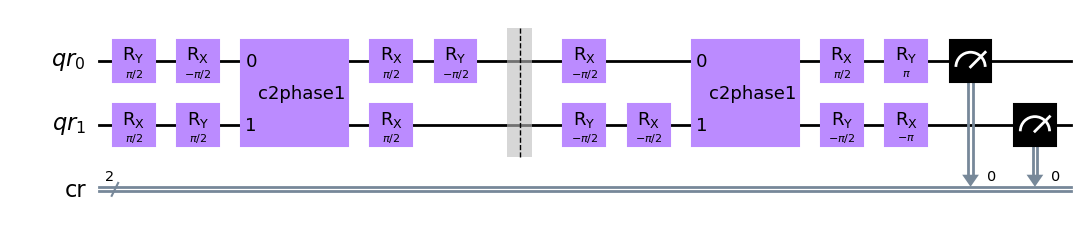

In [37]:
idx_ncliff = 0
idx_rand = 1
#idx_cut =  get_idx_first_cx(qudi_gates[idx_ncliff][idx_rand]) -1
#idx_cut =  get_idx_first_cx(qudi_gates[idx_ncliff][idx_rand])    # after 1st CNOT
idx_cut = None



# Fast: convert qudi->qc only for this index
# params = {'n_qubits': 2}
qc = create_qc_from_qudi(qudi_gates[idx_ncliff][idx_rand], idx_cut=idx_cut)

# Slow: use list of all converted qcs
#qc = rb_circs_native[idx_ncliff][idx_rand]

qc.draw('mpl')



In [38]:
# Old: work on qudi_gates
clif_length_vector = [2, 4, 8, 16, 32, 48, 64, 96, 128, 144] #  [1, 2, 3, 4]#
clif_length_vector =   [1, 2, 3, 4, 5, 6, 7, 8, 9 ]#
#clif_length_vector =   [1, 2, 3]
#n1q_pg = get_n_1q_rot(qc, basis_gates=['rx', 'ry'])
n1q_pg = calc_1q(qudi_gates, basis_gates=['rx', 'ry'])

# New: load as qiskit qcs
#clif_length_vector = rb_opts['length_vector']
#n1q_pg = calc_1q(rb_circs_native, basis_gates=['rx', 'ry'])

# count mean, median 1q gates per idx_cliff
n1q =  np.mean(n1q_pg, axis=1)
qudi_gates[0][0][0]

n1q_per_cliff = np.asarray(n1q)/np.asarray(clif_length_vector)
np.mean(n1q_per_cliff),  n1q, qudi_gates[0][0][0],

(10.531453634085214,
 array([14.05263158, 24.63157895, 33.26315789, 41.15789474, 49.26315789,
        62.10526316, 63.52631579, 70.63157895, 80.36842105]),
 '### Benchmark Sequence 1/171 ###\n# {"idx_info": {"n_cliff": 1, "idx_cliff": 0, "idx_random": 0}}# {"n_qubits": 2, "force_n_cx_const": true, "strip_cnot": false, "timestamp": "20230914-1200-43+20230914-1224-07", "qiskit_version": "0.23.0", "rb_options": {"length_vector": [1, 2, 3, 4, 5, 6, 7, 8, 9], "nseeds": 100, "rb_pattern": [[0, 1]], "interleaved_gates": [], "length_multiplier": 1}}# Columns: operation | params | idx_qubit\n')

In [64]:
n1q

array([ 30.52380952,  51.33333333,  75.80952381, 100.0952381 ,
       103.85714286, 137.19047619, 149.38095238, 173.57142857])

## Optimize # 1Q gates

In [193]:
# create a own transpile target for optimizing
# TOOD: not working for target!=None

from qiskit.transpiler import Target, InstructionProperties
from qiskit.circuit.library import RXGate, RYGate

custom_target = Target()

dummy_error_1q = None
gateset_rots = [1/3, 2/3, 0.25, 0.5, 1, 2, -1/3, -2/3, -0.25, -0.5, -1, -2]
gateset_rots = [ 0.5, 1., -0.5, -1.,]
gateset_phis_deg = [0, 90]
gateset_qubits = [(0,), (1,)]

for rot in gateset_rots:
    for phi in gateset_phis_deg:
        for qubit in gateset_qubits:
            rx_props = {
                qubit: InstructionProperties(error=dummy_error_1q)
            }
            if phi == 0:
                gate = RXGate(rot*math.pi)
            elif phi == 90:
                gate = RYGate(rot*math.pi)
            custom_target.add_instruction(gate, rx_props, name=f'r{phi}deg_on={qubit}_{rot}')
        


In [426]:
len(rb_circs_native[0])

21

In [14]:


#target = custom_target  # None
target = None  # free optimization, also allowing parametrized gates

qudi_gates_opt = []

#for idx_cliff, circs in enumerate(qudi_gates):   # for loaded fates (fast)
for idx_cliff, circs in enumerate(rb_circs_native):
    qudi_circs = []
    for idx_rand, qc in enumerate(circs):
        
        qc_opt = optimize_circ_q1(qc)
        
        qudi_circs.append(qc_opt)
    
    qudi_gates_opt.append(qudi_circs)



In [15]:
qudi_gates_opt[0][0]

In [408]:
3.141592653589793/np.pi

1.0

In [364]:
# Determine rotation angle of all 1q gates

def calc_1q_rot_angles(rb_circs, ignore_rots=[1., 0.5]):
    rots, rot_params = [], []
    normal_rots = ignore_rots
    special_rots = []

    for idx_cliff, circs in enumerate(rb_circs):
        qudi_circs = []
        for idx_rand, circ in enumerate(circs): 
            steps_q1, steps_q2 = circuit_2_step_list(circ), circuit_2_step_list(circ, qubit_idx=1)
            steps = steps_q1+steps_q2
            rot_params.extend([float(p[0][1][0]) for p in steps if len(p[0][1])>0])
            rots.extend([(float(p[0][1][0]), p[0][0]) for p in steps if len(p[0][1])>0])

    for rot in rots:
        is_close = False
        for normal in normal_rots:
            if np.isclose(abs(rot[0]/np.pi), normal, rtol=1e-8):
                is_close = True
        if not is_close:
            rot_pix = (round(rot[0]/np.pi, 9), rot[1]) 
            if rot_pix not in special_rots:
                special_rots.append(rot_pix)

    np.unique(rot_params)/np.pi

    return sorted(special_rots, key=lambda x: abs(x[0]))

calc_1q_rot_angles(rb_circs_native, ignore_rots=[0.5,1.0])

[]

In [378]:
steps_q1[0][0][0

('rx', [3.141592653589793])

In [38]:
# Calculate the efficiency of the optimization

n1q_pg = calc_1q(rb_circs_native, basis_gates=['rx', 'ry'])
n1q_pg_opt = calc_1q(qudi_gates_opt, basis_gates=['rx', 'ry'])
n1q =  np.mean(n1q_pg, axis=1)
n1q_opt = np.mean(n1q_pg_opt, axis=1)

n1q, n1q_opt
n1q_opt/n1q

array([0.3880814 , 0.3502994 , 0.3216285 , 0.3416339 , 0.32043821,
       0.3071317 , 0.33041336, 0.31428571, 0.31374563])

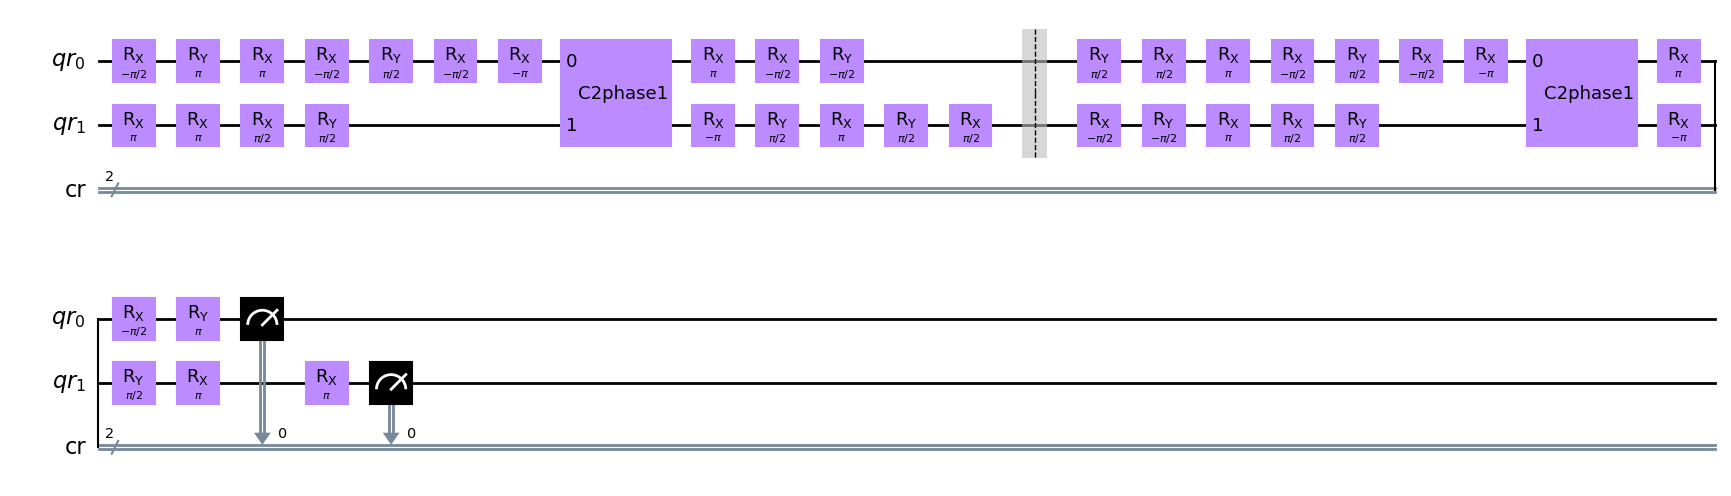

In [39]:
idx_cliff, idx_rand = 0,1
#qc = create_qc_from_qudi(qudi_gates[idx_cliff][idx_rand])
qc = rb_circs_native[idx_cliff][idx_rand]
qc.draw('mpl')

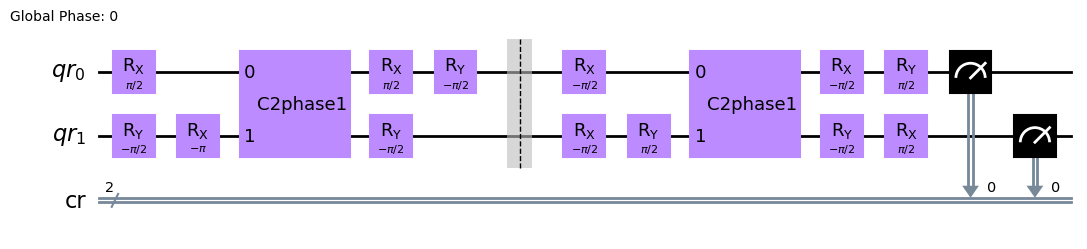

In [40]:
qudi_gates_opt[idx_cliff][idx_cliff].draw('mpl')

In [41]:
rb_circs_native = qudi_gates_opt

## Plot

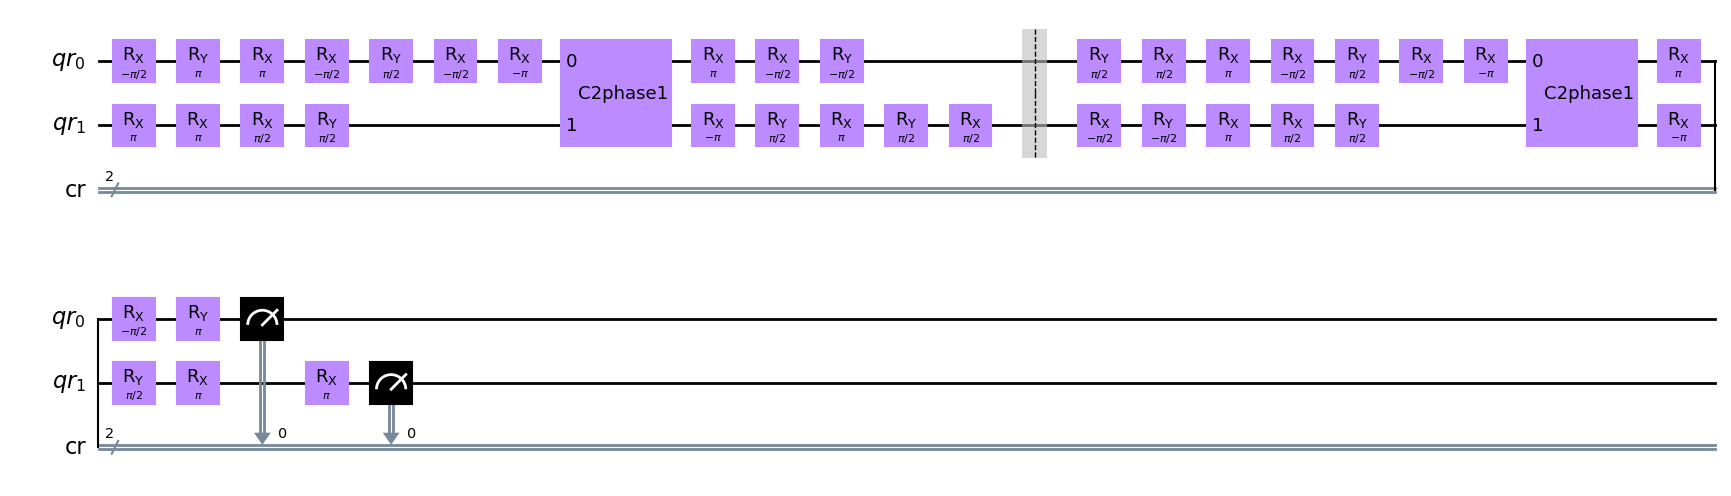

In [34]:
idx_cliff, idx_rand = 0,1
qc = rb_circs_native[idx_cliff][idx_rand]

qc.draw('mpl')

In [295]:
from qiskit.visualization import plot_state_city, plot_bloch_multivector

sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['rx','ry','id','cx'] # use U,CX for now
qc.save_statevector()
out_vec = sim.run(qc).result().get_statevector()

#qc.save_unitary()
#unitary = sim.run(qc).result().get_unitary()


array_to_latex(out_vec, prefix="\\text{Out_vec} = ")

plot_state_city(out_vec)
plot_bloch_multivector(out_vec)

Simulation failed and returned the following error message:
ERROR: Failed to load qobj: Unable to cast Python instance to C++ type (#define PYBIND11_DETAILED_ERROR_MESSAGES or compile in debug mode for details)


QiskitError: 'You have to select a circuit or schedule when there is more than one available'

In [303]:
from qiskit.quantum_info import entanglement_of_formation, partial_trace
import qiskit.opflow as ops_sigma

entanglement_of_formation(out_vec)
ops_sigma.Z

PauliOp(Pauli('Z'), coeff=1.0)

### Plot target, control in superposition before 1st CNOT

In [344]:
def state_on_qubit_equator(vector, qubit=0):
    
    idx_subsys = 0 if qubit==1 else 1
    if qubit > 1:
        raise NotImplementedError
    
    vec_len =  np.real(partial_trace(vector, [idx_subsys]).purity())
    vec_z = partial_trace(vector, [idx_subsys]).expectation_value(ops_sigma.Z)
    is_on_eq = np.isclose(vec_len, 1) and np.isclose(vec_z, 0)
    
    return is_on_eq
    
state_on_qubit_equator(out_vec, qubit=1)

True

In [360]:
from qiskit.quantum_info import entanglement_of_formation
entanglement_of_formation(out_vec)

idx_ncliff = 0

sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['rx','ry','id','cx'] 

x_axis, y_eq = [], []
for idx, qd_gates in enumerate(qudi_gates[idx_ncliff]):  
    idx_cut =  get_idx_first_cx(qd_gates) - 1
    qc = create_qc_from_qudi(qd_gates, idx_cut=idx_cut)

    qc.save_statevector()
    out_vec = sim.run(qc).result().get_statevector()
    eq_1 = state_on_qubit_equator(out_vec, qubit=0)
    eq_2 = state_on_qubit_equator(out_vec, qubit=1)
    eq_both = eq_1 and eq_2
    y = 0
    if eq_1:
        y = 1
    if eq_2:
        y = 2
    if eq_both:
        y = 3
    
    x_axis.append(idx)
    y_eq.append(y)
    



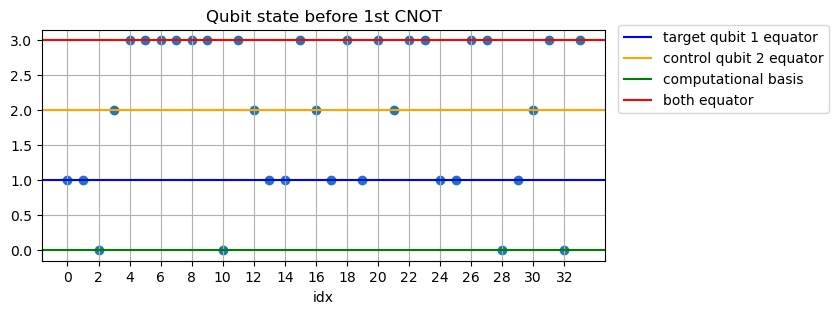

In [371]:

plt.figure(figsize=(16,3))
ax = plt.subplot(121)

#plt.plot(x_axis, np.asarray(y_eq))
plt.scatter(x_axis, np.asarray(y_eq))
plt.axhline(1, label='target qubit 1 equator', color='blue')
plt.axhline(2, label='control qubit 2 equator', color='orange')
plt.axhline(0, label='computational basis', color='green')
plt.axhline(3, label='both equator', color='red')

plt.xticks(x_axis[::2])
plt.xlabel("idx")
plt.grid()
plt.title("Qubit state before 1st CNOT")

ax.legend(bbox_to_anchor=(1.01, 1.05))

### Plot entanglement after 1st CNOT

Rand benchmarking sequences that create entanglement might be more prone to errors.

In [265]:
from qiskit.quantum_info import entanglement_of_formation
entanglement_of_formation(out_vec)

idx_ncliff = 0

sim = qiskit.Aer.get_backend('aer_simulator')
basis_gates = ['rx','ry','id','cx'] # use U,CX for now

x_axis, y_ent = [], []
for idx, qd_gates in enumerate(qudi_gates[idx_ncliff]):  
    idx_cut =  get_idx_first_cx(qd_gates) 
    qc = create_qc_from_qudi(qd_gates, idx_cut=idx_cut)

    qc.save_statevector()
    out_vec = sim.run(qc).result().get_statevector()
    x_axis.append(idx)
    y_ent.append(entanglement_of_formation(out_vec))
    



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


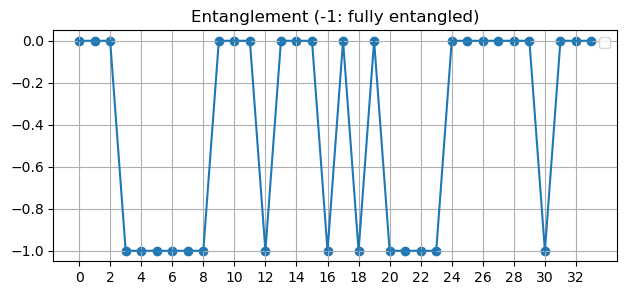

In [267]:

plt.figure(figsize=(16,3))
plt.subplot(121)

plt.plot(x_axis, -np.asarray(y_ent))
plt.scatter(x_axis, -np.asarray(y_ent))
plt.xticks(x_axis[::2])

plt.xlabel("idx")
plt.grid()
plt.title("Entanglement (-1: fully entangled)")
plt.legend()

### Plot number of 1q, 2q gates for same n_cliff

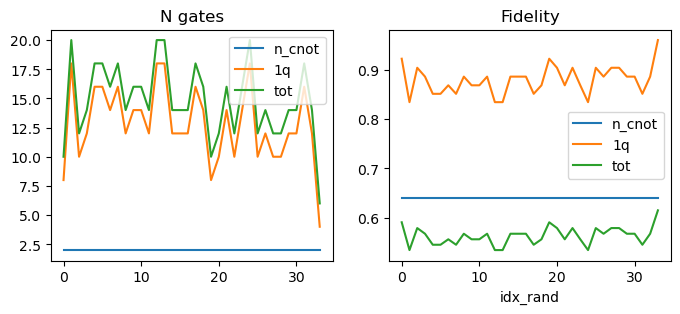

array([ 8, 18, 10, 12, 16, 16, 14, 16, 12, 14, 14, 12, 18, 18, 12, 12, 12,
       16, 14,  8, 10, 14, 10, 14, 18, 10, 12, 10, 10, 12, 12, 16, 12,  4])

In [101]:
err_rate_1q = 0.99
err_rate_2q = 0.8

idx_cliff = 0
ys_cx, ys_1q = [], []
for idx_rand, circ in enumerate(qudi_gates[idx_cliff]):
    y_cx, y_1q = get_n_cx(circ), get_n_1q_rot(circ)
    ys_cx.append(y_cx)
    ys_1q.append(y_1q)
    
ys_cx, ys_1q = np.asarray(ys_cx), np.asarray(ys_1q)

plt.figure(figsize=(8,3))
plt.subplot(121)

plt.plot(ys_cx, label='n_cnot')
plt.plot(ys_1q, label='1q')
plt.plot(np.asarray(ys_1q)+np.asarray(ys_cx), label='tot')
plt.title("N gates")
plt.legend()

plt.subplot(122)
plt.plot(err_rate_2q**ys_cx, label='n_cnot')
plt.plot(err_rate_1q**ys_1q, label='1q')
plt.plot((err_rate_1q**ys_1q * err_rate_2q**ys_cx)/1, label='tot')
plt.title("Fidelity")
plt.legend()

plt.xlabel("idx_rand")
plt.show()

ys_1q

In [322]:
err_rate_1q**ys_cx, err_rate_2q**ys_cx

(array([0.96059601, 0.96059601, 0.96059601, 0.9801    , 0.96059601,
        0.96059601, 0.96059601, 0.9801    , 0.9801    , 1.        ]),
 array([0.4096, 0.4096, 0.4096, 0.64  , 0.4096, 0.4096, 0.4096, 0.64  ,
        0.64  , 1.    ]))

In [313]:
qudi_gates[idx_cliff][0][1]

[[['rx', [1.5707963267948966]], [0]],
 [['rx', [3.141592653589793]], [1]],
 [['ry', [1.5707963267948966]], [0]],
 [['cx', []], [0, 1]],
 [['rx', [-1.5707963267948966]], [0]],
 [['rx', [-1.5707963267948966]], [1]],
 [['ry', [-1.5707963267948966]], [0]],
 [['ry', [-1.5707963267948966]], [1]],
 [['barrier', []], [0, 1]],
 [['ry', [1.5707963267948966]], [0]],
 [['ry', [1.5707963267948966]], [1]],
 [['rx', [1.5707963267948966]], [0]],
 [['rx', [1.5707963267948966]], [1]],
 [['cx', []], [0, 1]],
 [['ry', [-1.5707963267948966]], [0]],
 [['rx', [3.141592653589793]], [1]],
 [['rx', [-1.5707963267948966]], [0]],
 [['measure', []], [1]],
 [['measure', []], [0]]]

In [304]:
qudi_gates[idx_cliff][1][1]

[[['rx', [3.141592653589793]], [0]],
 [['rx', [-1.5707963267948966]], [1]],
 [['ry', [1.5707963267948961]], [1]],
 [['cx', []], [0, 1]],
 [['rx', [-1.5707963267948966]], [0]],
 [['ry', [1.5707963267948966]], [1]],
 [['ry', [-1.5707963267948966]], [0]],
 [['rx', [1.5707963267948966]], [1]],
 [['barrier', []], [0, 1]],
 [['ry', [1.5707963267948966]], [0]],
 [['rx', [-1.5707963267948966]], [1]],
 [['rx', [1.5707963267948966]], [0]],
 [['ry', [-1.5707963267948966]], [1]],
 [['cx', []], [0, 1]],
 [['rx', [3.141592653589793]], [0]],
 [['ry', [-1.5707963267948966]], [1]],
 [['measure', []], [0]],
 [['rx', [1.5707963267948966]], [1]],
 [['measure', []], [1]]]

# Playground

In [509]:
pulse = qiskit.pulse.Drag(100, 1, 25, 0.01) # duration, amp, sigma, beta

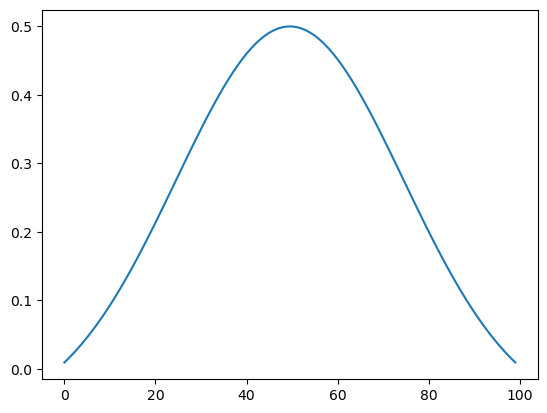

In [508]:
plt.plot(pulse.get_waveform().samples)
plt.show()

In [165]:

u_cphase = np.asarray([[1, 0,  0,  0],
          [0, 1j, 0,  0],
          [0, 0,  1j, 0],
          [0, 0,  0,  1]])
rho1 = np.asarray([[0.5, 0.5], [0.5, 0.5]])
rho2 = np.asarray([[0.8, 0], [0, 0]])

pix = np.asarray([[0, 1],[1,0]])
piy = np.asarray([[0, -1j],[1j,0]])
pi2x = scipy.linalg.sqrtm(pix)
pi2y = scipy.linalg.sqrtm(piy)


pi2x_on1 = np.kron(pi2x, np.eye(2))
pi2y_on1 = np.kron(pi2y, np.eye(2))

rho_in = np.kron(rho1, rho2)
rho_cphase = np.matmul(np.matmul(u_cphase, rho_in), np.conj(u_cphase.T))
rho1, np.matmul(np.matmul(pi2x_on1, rho_cphase), np.conj(pi2x_on1.T))

#rho1, np.matmul(np.matmul(pi2y, rho1), np.conj(pi2y.T))



(array([[0.5, 0.5],
        [0.5, 0.5]]),
 array([[0.8+0.j, 0. +0.j, 0. +0.j, 0. +0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j],
        [0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j]]))

In [136]:
pi2x

array([[1.54308063, 1.17520119],
       [1.17520119, 1.54308063]])

(9.612499162281463e-05, 0.01804756815205541)